# Procesamiento de Alto Volumen de Datos
### Taller: Tratamiento de Datos y Machine Learning con PySpark

**Pontificia Universidad Javeriana**

| Campo | Detalle |
|---|---|
| Autor | Juan Diego Muñoz Angulo |
| Fecha | 20/05/1026 |
| Tema | Clasificación y métricas de aprendizaje en dataset de banco |
| Objetivo | Analizar el rendimiento de diferentes modelos de clasificación usando un dataset de la banca portuguesa. |

## Contexto del conjunto de datos

Los datos corresponden a campañas de marketing directo de una institución bancaria portuguesa, realizadas mediante llamadas telefónicas. En muchos casos fue necesario contactar al mismo cliente más de una vez para determinar si contrataba o no un depósito a plazo.

### Archivos disponibles

1. **bank-additional-full.csv**: contiene 41,188 registros y 20 variables de entrada, ordenados por fecha (mayo de 2008 a noviembre de 2010), similares a los analizados en Moro et al. (2014).
2. **bank-additional.csv**: contiene el 10% del conjunto anterior (4,119 registros), con las mismas 20 variables de entrada.
3. **bank-full.csv**: versión previa con todos los ejemplos y 17 variables de entrada.
4. **bank.csv**: contiene el 10% del conjunto anterior de 17 variables.

Los conjuntos pequeños se incluyen para probar algoritmos de aprendizaje automático más costosos computacionalmente (por ejemplo, SVM).

## Meta de clasificación

Predecir si el cliente contratará (`yes`) o no (`no`) un depósito a plazo (variable objetivo `y`).

# High-Volume Data Processing (Procesamiento de Datos a Gran Escala)
### Workshop: Data Treatment and Machine Learning with PySpark

**Pontificia Universidad Javeriana**

| Field | Detail |
|---|---|
| Author | Juan Diego Muñoz Angulo |
| Date | 20/05/1026 |
| Topic | Classification and learning metrics in a banking dataset |
| Objective | Analyze the performance of different classification models using a Portuguese banking dataset. |

## Dataset Context

The data corresponds to direct marketing campaigns of a Portuguese banking institution, conducted through phone calls. In many cases, it was necessary to contact the same client more than once to determine whether they would subscribe to a term deposit.

### Available Files

1. **bank-additional-full.csv**: Contains 41,188 records and 20 input variables, ordered by date (May 2008 to November 2010), similar to those analyzed in Moro et al. (2014).
2. **bank-additional.csv**: Contains 10% of the previous dataset (4,119 records), with the same 20 input variables.
3. **bank-full.csv**: Previous version with all examples and 17 input variables.
4. **bank.csv**: Contains 10% of the previous dataset with 17 variables.

The smaller datasets are included to test computationally expensive machine learning algorithms (e.g., SVM).

## Goal

Predict whether the client will subscribe (`yes`) or not (`no`) to a term deposit (target variable `y`).

In [1]:
# BLOQUE DE VERIFICACION Y AUTO-CORRECCION DE ENTORNO SPARK
# Esto lo ponemos porque la instalacion de pyspark se rompe mucho so jeje

import subprocess, sys, os

SPARK_VERSION_REQUERIDA = "3.5.8"

def verificar_y_corregir_pyspark():
    print("-" * 50)
    print("Verificando entorno PySpark...")
    print("-" * 50)

    # 1. Version de PySpark instalada via pip
    resultado = subprocess.run(
        ["pip", "show", "pyspark"],
        capture_output=True, text=True
    )
    version_pip = None
    for linea in resultado.stdout.splitlines():
        if linea.startswith("Version:"):
            version_pip = linea.split(":")[1].strip()

    print(f"PySpark (pip):   {version_pip or 'NO ENCONTRADO'}")
    print(f"Spark requerido: {SPARK_VERSION_REQUERIDA}")

    # 2. Hay conflicto?
    if version_pip != SPARK_VERSION_REQUERIDA:
        print(f"\nConflicto: pip tiene {version_pip}, el cluster usa {SPARK_VERSION_REQUERIDA}")
        print("Corrigiendo automaticamente...\n")

        subprocess.run(
            [sys.executable, "-m", "pip", "uninstall", "pyspark", "-y"],
            check=True
        )
        subprocess.run(
            [sys.executable, "-m", "pip", "install",
             f"pyspark=={SPARK_VERSION_REQUERIDA}", "-q"],
            check=True
        )
        print(f"\nPySpark {SPARK_VERSION_REQUERIDA} instalado correctamente.")
        print("REINICIA EL KERNEL ahora (Kernel -> Restart Kernel)")
        print("y vuelve a ejecutar desde esta celda.\n")
        return False
    else:
        print(f"Version correcta: {version_pip}")

    # 3. Variables de entorno criticas
    spark_home = os.environ.get("SPARK_HOME", "")
    java_home  = os.environ.get("JAVA_HOME", "")
    print(f"SPARK_HOME: {spark_home or 'NO DEFINIDO'}")
    print(f"JAVA_HOME:  {java_home  or 'NO DEFINIDO'}")

    if not spark_home:
        print("SPARK_HOME no definido, buscando en /Almacen/Spark...")
        if os.path.exists("/Almacen/Spark"):
            os.environ["SPARK_HOME"] = "/Almacen/Spark"
            print("SPARK_HOME establecido en /Almacen/Spark")
        else:
            print("No se encontro /Almacen/Spark - revisa el montaje HDFS.")

    # 4. Verificar que los JARs existen
    jars_path = os.path.join(os.environ.get("SPARK_HOME", ""), "jars")
    if os.path.isdir(jars_path):
        jars = [f for f in os.listdir(jars_path) if "spark-core" in f]
        print(f"JARs spark-core: {jars[0] if jars else 'NO ENCONTRADO'}")
    else:
        print("Directorio de JARs no accesible.")

    print("-" * 50)
    print("Entorno OK - puedes continuar.\n")
    return True

entorno_ok = verificar_y_corregir_pyspark()

--------------------------------------------------
Verificando entorno PySpark...
--------------------------------------------------
PySpark (pip):   3.5.8
Spark requerido: 3.5.8
Version correcta: 3.5.8
SPARK_HOME: /Almacen/Spark
JAVA_HOME:  NO DEFINIDO
JARs spark-core: spark-core_2.12-3.5.8.jar
--------------------------------------------------
Entorno OK - puedes continuar.



In [2]:
import sys
import glob
import findspark
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pylab import *
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from sklearn.metrics import roc_curve, auc
from pyspark.sql.types import *
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.classification import DecisionTreeClassifier

In [3]:
findspark.init()

if entorno_ok:
    # Creación de la configuración sin parámetros iniciales
    # Creating the configuration without initial parameters
    configura = SparkConf()
    
    configura.set("spark.scheduler.mode","FAIR")
    configura.set("spark.scheduler.allocation","/Almacen/Spark/conf/fairscheduler.xml")
    
    # Configuración de este equipo como el nodo maestro del clúster
    # Setting up this machine as the master node of the cluster
    configura.setMaster("spark://10.43.97.190:7077")   
    configura.setAppName("Taller_Banca_Metricas")

    sparkMunoz = SparkSession.builder.config(conf=configura).getOrCreate()

    sparkMunoz
else:
    print("Reinicia el kernel antes de continuar.")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 22:43:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
# Inicialización del DataFrame cargando datos bancarios
# DataFrame initialization by loading banking data
df00 = (
    sparkMunoz.read
    .format("csv")
    .option("header", "true")
    .option("sep", ";")
    .option("inferSchema", "true")
    .load("/Almacen/bank-full.csv")
)

df00.show(5)

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

# Variables del Dataset
## Tabla de Variables
| Nombre de la Variable | Rol | Tipo | Demografía | Descripción | Unidades | Valores Faltantes |
|---|---|---|---|---|---|---|
| **age** | Característica | Entero | Edad | Edad del cliente | — | No |
| **job** | Característica | Categórica | Ocupación | Tipo de trabajo (`admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`) | — | No |
| **marital** | Característica | Categórica | Estado Civil | Estado civil (`divorced`, `married`, `single`, `unknown`). *Divorced incluye divorciado o viudo* | — | No |
| **education** | Característica | Categórica | Nivel Educativo | Nivel educativo (`basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`) | — | No |
| **default** | Característica | Binaria | — | ¿Tiene crédito en mora? | — | No |
| **balance** | Característica | Entero | — | Balance promedio anual | Euros | No |
| **housing** | Característica | Binaria | — | ¿Tiene préstamo hipotecario? | — | No |
| **loan** | Característica | Binaria | — | ¿Tiene préstamo personal? | — | No |
| **contact** | Característica | Categórica | — | Tipo de comunicación de contacto (`cellular`, `telephone`) | — | Sí |
| **day_of_week** | Característica | Fecha | — | Último día de contacto de la semana | — | — |
---
## Descripción General
Este conjunto de variables describe características **demográficas, financieras y de contacto** de clientes bancarios.
Las variables pueden agruparse en:
### Variables demográficas
- `age`
- `job`
- `marital`
- `education`
### Variables financieras
- `default`
- `balance`
- `housing`
- `loan`
### Variables de contacto
- `contact`
- `day_of_week`
---
## Tipo de Datos
### Numéricas
- `age`
- `balance`
### Categóricas
- `job`
- `marital`
- `education`
- `contact`
### Binarias
- `default`
- `housing`
- `loan`
### Temporales
- `day_of_week`
---
## Observaciones
- La mayoría de variables **no presentan valores faltantes**.
- `contact` sí puede contener valores ausentes.
- Variables categóricas como `job`, `marital` y `education` requerirán **codificación (Encoding)** para modelos de Machine Learning.
- Variables binarias pueden transformarse fácilmente a valores **0 / 1**.
---
# Dataset Variables
## Variable Table
| Variable Name | Role | Type | Demographic | Description | Units | Missing Values |
|---|---|---|---|---|---|---|
| **age** | Feature | Integer | Age | Client's age | — | No |
| **job** | Feature | Categorical | Occupation | Job type (`admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`) | — | No |
| **marital** | Feature | Categorical | Marital Status | Marital status (`divorced`, `married`, `single`, `unknown`). *Divorced includes divorced or widowed* | — | No |
| **education** | Feature | Categorical | Education Level | Education level (`basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`) | — | No |
| **default** | Feature | Binary | — | Does the client have default credit? | — | No |
| **balance** | Feature | Integer | — | Average yearly balance | Euros | No |
| **housing** | Feature | Binary | — | Does the client have a housing loan? | — | No |
| **loan** | Feature | Binary | — | Does the client have a personal loan? | — | No |
| **contact** | Feature | Categorical | — | Type of contact communication (`cellular`, `telephone`) | — | Yes |
| **day_of_week** | Feature | Date | — | Last contact day of the week | — | — |
---
## General Description
This set of variables describes **demographic, financial, and contact** characteristics of bank clients.
The variables can be grouped into:
### Demographic Variables
- `age`
- `job`
- `marital`
- `education`
### Financial Variables
- `default`
- `balance`
- `housing`
- `loan`
### Contact Variables
- `contact`
- `day_of_week`
---
## Data Types
### Numerical
- `age`
- `balance`
### Categorical
- `job`
- `marital`
- `education`
- `contact`
### Binary
- `default`
- `housing`
- `loan`
### Temporal
- `day_of_week`
---
## Observations
- Most variables **do not have missing values**.
- `contact` may contain missing values.
- Categorical variables like `job`, `marital`, and `education` will require **encoding** for Machine Learning models.
- Binary variables can be easily transformed into **0 / 1** values.

In [5]:
# Impresión del listado de columnas disponibles en el DataFrame
# Printing the list of columns available in the DataFrame
print(df00.columns)

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [6]:
# Inspección del esquema y los tipos de datos del DataFrame
# Inspection of the DataFrame schema and data types
df00.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



# Análisis de las Variables
El conjunto de datos incluye un total de **18 variables**, de las cuales **17 son predictoras** y **1 es la variable objetivo (`y`)**. Estas variables abarcan información clave en tres categorías principales:
1. **Demográfica**: Datos relacionados con características personales de los clientes.
2. **Financiera**: Información sobre el estado económico de los clientes.
3. **Campañas de Marketing**: Detalles sobre interacciones previas con campañas.
---
## Resumen de las Variables
### Variables Predictoras
- **Demográficas**:
  - `age`: Edad del cliente.
  - `job`: Ocupación.
  - `marital`: Estado civil.
  - `education`: Nivel educativo.
- **Financieras**:
  - `default`: Crédito en mora.
  - `balance`: Balance promedio anual.
  - `housing`: Préstamo hipotecario.
  - `loan`: Préstamo personal.
- **De Marketing**:
  - `contact`: Tipo de contacto.
  - `day_of_week`: Día de la semana del último contacto.
### Variable Objetivo
- `y`: Indica si el cliente suscribió un depósito a plazo fijo.
---
## Observaciones Adicionales
- **Distribución de Datos**: La mayoría de las variables están completas, con pocos valores faltantes.
- **Codificación Necesaria**: Las variables categóricas como `job`, `marital` y `education` deben ser transformadas para su uso en modelos de Machine Learning.
- **Transformación de Binarias**: Las variables binarias (`default`, `housing`, `loan`) pueden convertirse fácilmente a valores numéricos (0 y 1).
- **Importancia de la Variable Objetivo**: La variable `y` es crucial para evaluar el éxito de las campañas de marketing.
---
# Variable Observations
The dataset comprises **18 variables**, including **17 predictors** and **1 target variable (`y`)**. These variables provide insights into three main categories:
1. **Demographic**: Personal characteristics of clients.
2. **Financial**: Economic status of clients.
3. **Marketing Campaigns**: Details about previous interactions with campaigns.
---
## Variable Summary
### Predictor Variables
- **Demographic**:
  - `age`: Client's age.
  - `job`: Occupation.
  - `marital`: Marital status.
  - `education`: Education level.
- **Financial**:
  - `default`: Default credit.
  - `balance`: Average yearly balance.
  - `housing`: Housing loan.
  - `loan`: Personal loan.
- **Marketing**:
  - `contact`: Type of contact.
  - `day_of_week`: Day of the week of the last contact.
### Target Variable
- `y`: Indicates whether the client subscribed to a term deposit.
---
## Additional Observations
- **Data Distribution**: Most variables are complete, with minimal missing values.
- **Encoding Required**: Categorical variables like `job`, `marital`, and `education` need transformation for Machine Learning models.
- **Binary Transformation**: Binary variables (`default`, `housing`, `loan`) can be easily converted to numeric values (0 and 1).
- **Target Variable Importance**: The `y` variable is critical for assessing the success of marketing campaigns.

In [7]:
# Definición de estructuras de columnas y transformación de tipos de datos a entero
# Column structures definition and transformation of data types to integer
nombreColumnas = [
    'age', 'job', 'marital', 'education',
    'default', 'balance', 'housing',
    'loan', 'contact', 'day',
    'month', 'duration', 'campaign',
    'pdays', 'previous', 'poutcome', 'y'
]

columnas_Int = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

# Conversión secuencial de las columnas numéricas al tipo entero mediante casting
# Sequential conversion of numerical columns to integer type using casting
df01 = df00.withColumn("age", df00.age.cast("int"))
df01 = df01.withColumn("balance", df01.balance.cast("int"))
df01 = df01.withColumn("day", df01.day.cast("int"))
df01 = df01.withColumn("duration", df01.duration.cast("int"))
df01 = df01.withColumn("campaign", df01.campaign.cast("int"))
df01 = df01.withColumn("pdays", df01.pdays.cast("int"))
df01 = df01.withColumn("previous", df01.previous.cast("int"))

# Impresión del esquema final para validar los nuevos tipos de datos
# Printing the final schema to validate the new data types
df01.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



In [8]:
# Muestra de las primeras 10 filas del DataFrame para validación visual de los datos y su casting
# Display of the first 10 rows of the DataFrame for visual validation of data and its casting
df01.show(10)

+---+------------+--------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job| marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+--------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management| married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician|  single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur| married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar| married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown|  single|  unknown|     no|      1|     no|  no|unknown|  5|  may

# Transformación de Tipos de Datos
En esta sección, se realiza el **casting** de variables para asegurar que los datos tengan el tipo adecuado para su análisis y procesamiento.
---
## Método Utilizado
### Función `withColumn()`
- Permite **reemplazar** o **crear** columnas en un DataFrame.
- Es útil para realizar transformaciones específicas en columnas existentes.
### Método `cast("int")`
- Convierte el tipo de dato de una columna a **entero**.
- Es esencial para garantizar que las variables numéricas sean interpretadas correctamente.
---
## Ejemplo de Uso
```python
df = df.withColumn("columna", df["columna"].cast("int"))
```
En este ejemplo, la columna `columna` se transforma al tipo de dato entero.
---
# Data Type Transformation
This section focuses on **casting** variables to ensure that data types are appropriate for analysis and processing.
---
## Method Used
### Function `withColumn()`
- Allows **replacing** or **creating** columns in a DataFrame.
- Useful for applying specific transformations to existing columns.
### Method `cast("int")`
- Converts the data type of a column to **integer**.
- Essential for ensuring that numerical variables are correctly interpreted.
---
## Example Usage
```python
df = df.withColumn("column", df["column"].cast("int"))
```
In this example, the `column` is transformed to the integer data type.

In [9]:
# Cálculo del volumen total de datos en el DataFrame
# Calculation of the total data volume in the DataFrame
cantTotal = df00.count()

print(f"Cantidad total de registros del dataset = {cantTotal}\n")

# Agrupación y conteo de frecuencias por categoría de la variable objetivo
# Grouping and frequency counting by target variable category
cantY = df00.groupBy("y").count()

# Cálculo de la proporción porcentual de cada clase respecto al total
# Calculation of the percentage proportion of each class relative to the total
dfBalanceY = cantY.withColumn(
    "Porcentaje",
    (cantY["count"] * 100 / cantTotal)
)

# Transformación a estructura Pandas y ordenamiento descendente para su visualización
# Transformation to a Pandas structure and descending sorting for display
tablaBalanceY = (
    dfBalanceY
    .toPandas()
    .sort_values("count", ascending=False)
)

print("Distribución de la variable objetivo:")
tablaBalanceY

Cantidad total de registros del dataset = 45211



[Stage 7:=============================>                             (1 + 1) / 2]

Distribución de la variable objetivo:


,y,count,Porcentaje
0,no,39922,88.30152
1,yes,5289,11.69848


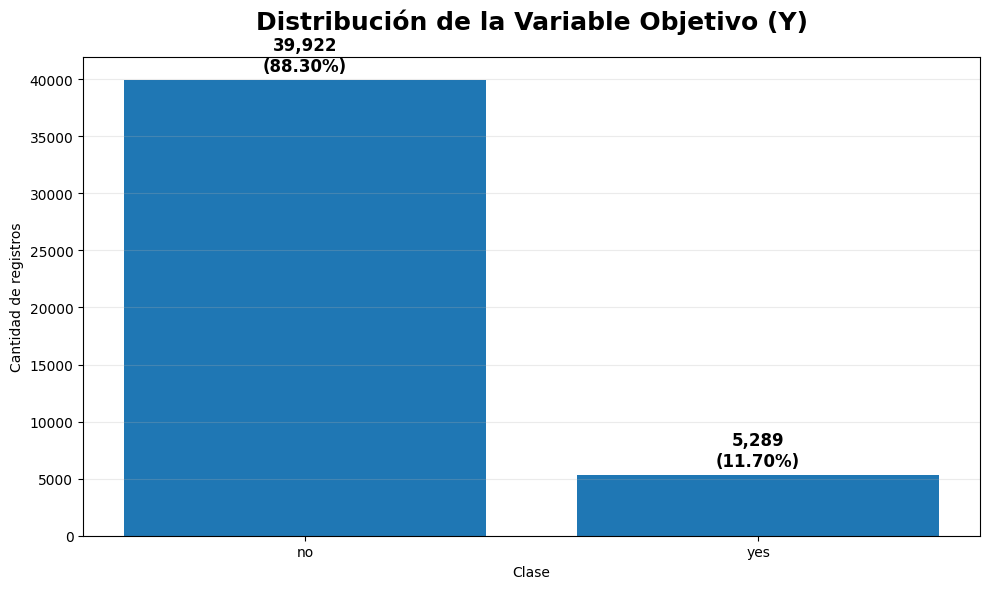

In [10]:
# Conversión del DataFrame de Spark a un DataFrame de Pandas estructurado
# Conversion of the Spark DataFrame into a structured Pandas DataFrame
tablaBalanceY = (
    dfBalanceY
    .toPandas()
    .sort_values("count", ascending=False)
)

# Inicialización y configuración de las dimensiones del lienzo del gráfico
# Initialization and configuration of the plot canvas dimensions
plt.figure(figsize=(10,6))

# Generación del gráfico de barras basado en la frecuencia de cada categoría
# Generation of the bar chart based on the frequency of each category
bars = plt.bar(
    tablaBalanceY["y"],
    tablaBalanceY["count"]
)

# Configuración del título principal, etiquetas de los ejes y formato del texto
# Configuration of the main title, axis labels, and text formatting
plt.title(
    "Distribución de la Variable Objetivo (Y)",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Clase")
plt.ylabel("Cantidad de registros")

# Incorporación de una cuadrícula de fondo atenuada en el eje vertical
# Inclusion of a dimmed background grid on the vertical axis
plt.grid(axis="y", alpha=0.25)

# Cálculo del valor máximo e iteración para renderizar las etiquetas métricas sobre cada barra
# Calculation of the maximum value and iteration to render metric labels over each bar
maximo = tablaBalanceY["count"].max()

for i, row in tablaBalanceY.iterrows():
    plt.text(
        i,
        row["count"] + maximo * 0.02,
        f'{row["count"]:,}\n({row["Porcentaje"]:.2f}%)',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

# Ajuste dinámico de los márgenes y despliegue final de la visualización
# Dynamic adjustment of margins and final display of the visualization
plt.tight_layout()
plt.show()

# Observaciones del Gráfico de la Variable Objetivo `Y`
En esta sección se analiza la distribución de la variable objetivo `Y` y sus implicaciones para el modelo.
---
## Principales Observaciones
1. **Desbalance Marcado**
   - La categoría **`no`** representa el **88.30%** de los registros, mientras que **`yes`** solo el **11.70%**.
2. **Impacto en el Modelo**
   - La clase mayoritaria puede sesgar el modelo hacia predicciones negativas.
3. **Representatividad Analítica**
   - Aunque minoritaria, la clase positiva tiene suficientes registros para análisis.
4. **Relación con Predictoras**
   - La distribución desigual sugiere explorar factores que influyen en respuestas positivas.
---
# Observations on Target Variable `Y`
This section analyzes the distribution of the target variable `Y` and its implications for the model.
---
## Key Observations
1. **Significant Imbalance**
   - The category **`no`** accounts for **88.30%** of records, while **`yes`** only **11.70%**.
2. **Model Impact**
   - The majority class may bias the model towards negative predictions.
3. **Analytical Representativeness**
   - Despite being a minority, the positive class has enough records for analysis.
4. **Relation to Predictors**
   - The uneven distribution suggests exploring factors influencing positive responses.

In [11]:
# Extracción del resumen estadístico descriptivo y conversión para presentación tabular
# Extraction of the descriptive statistical summary and conversion for tabular presentation
df01.describe().toPandas().head()

26/05/25 22:44:13 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


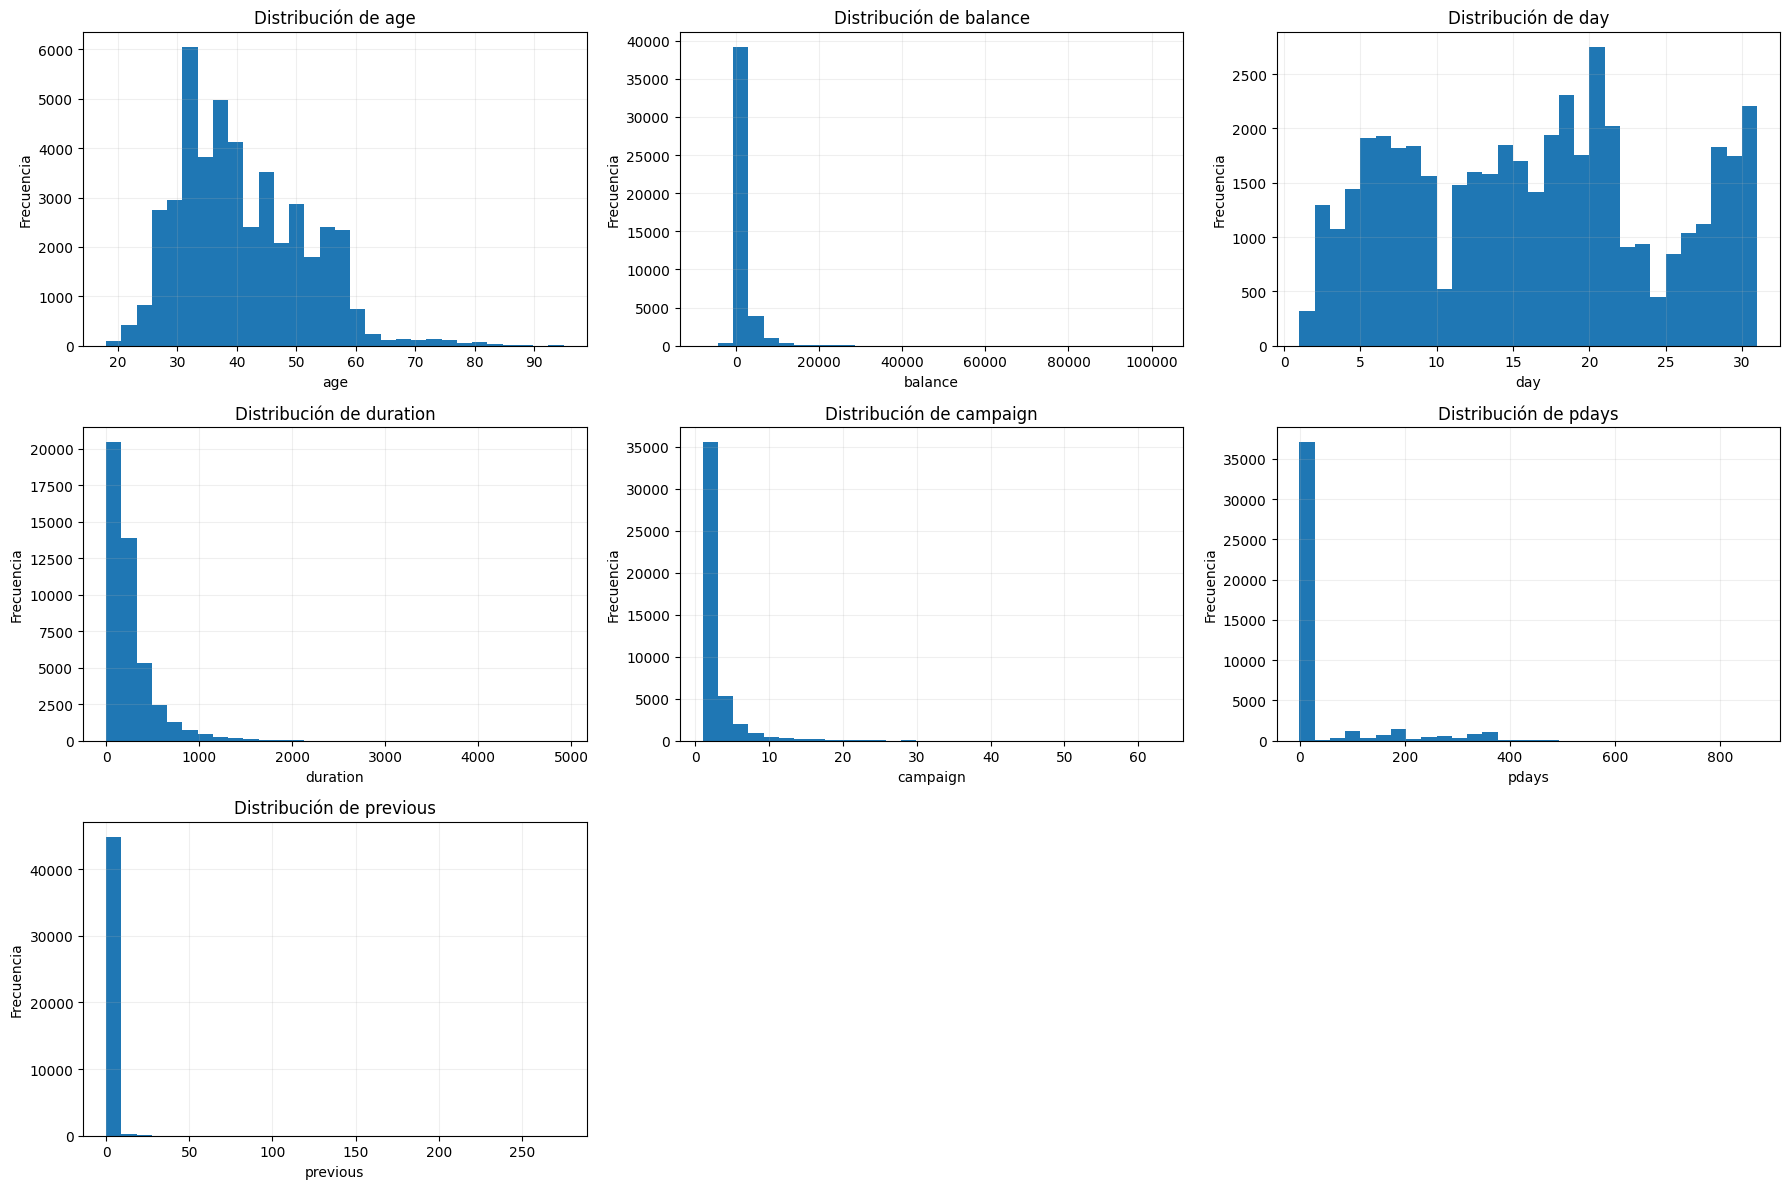

In [12]:
# Filtrado de variables cuantitativas y conversión a estructura local de Pandas
# Filtering of quantitative variables and conversion to a local Pandas structure
columnas_numericas = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

pdf_num = df01.select(columnas_numericas).toPandas()

# Configuración de la cuadrícula de gráficos y renderizado de histogramas distribucionales
# Grid configuration for plots and rendering of distributional histograms
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    axes[i].hist(pdf_num[col], bins=30)
    axes[i].set_title(f"Distribución de {col}", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(alpha=0.2)

# Remoción de los subplots remanentes que quedaron vacíos en la matriz
# Removal of the remaining subplots that were left empty in the matrix
for j in range(len(columnas_numericas), len(axes)):
    fig.delaxes(axes[j])

# Ajuste de márgenes periféricos y despliegue de las visualizaciones
# Adjustment of peripheral margins and deployment of the visualizations
plt.tight_layout()
plt.show()

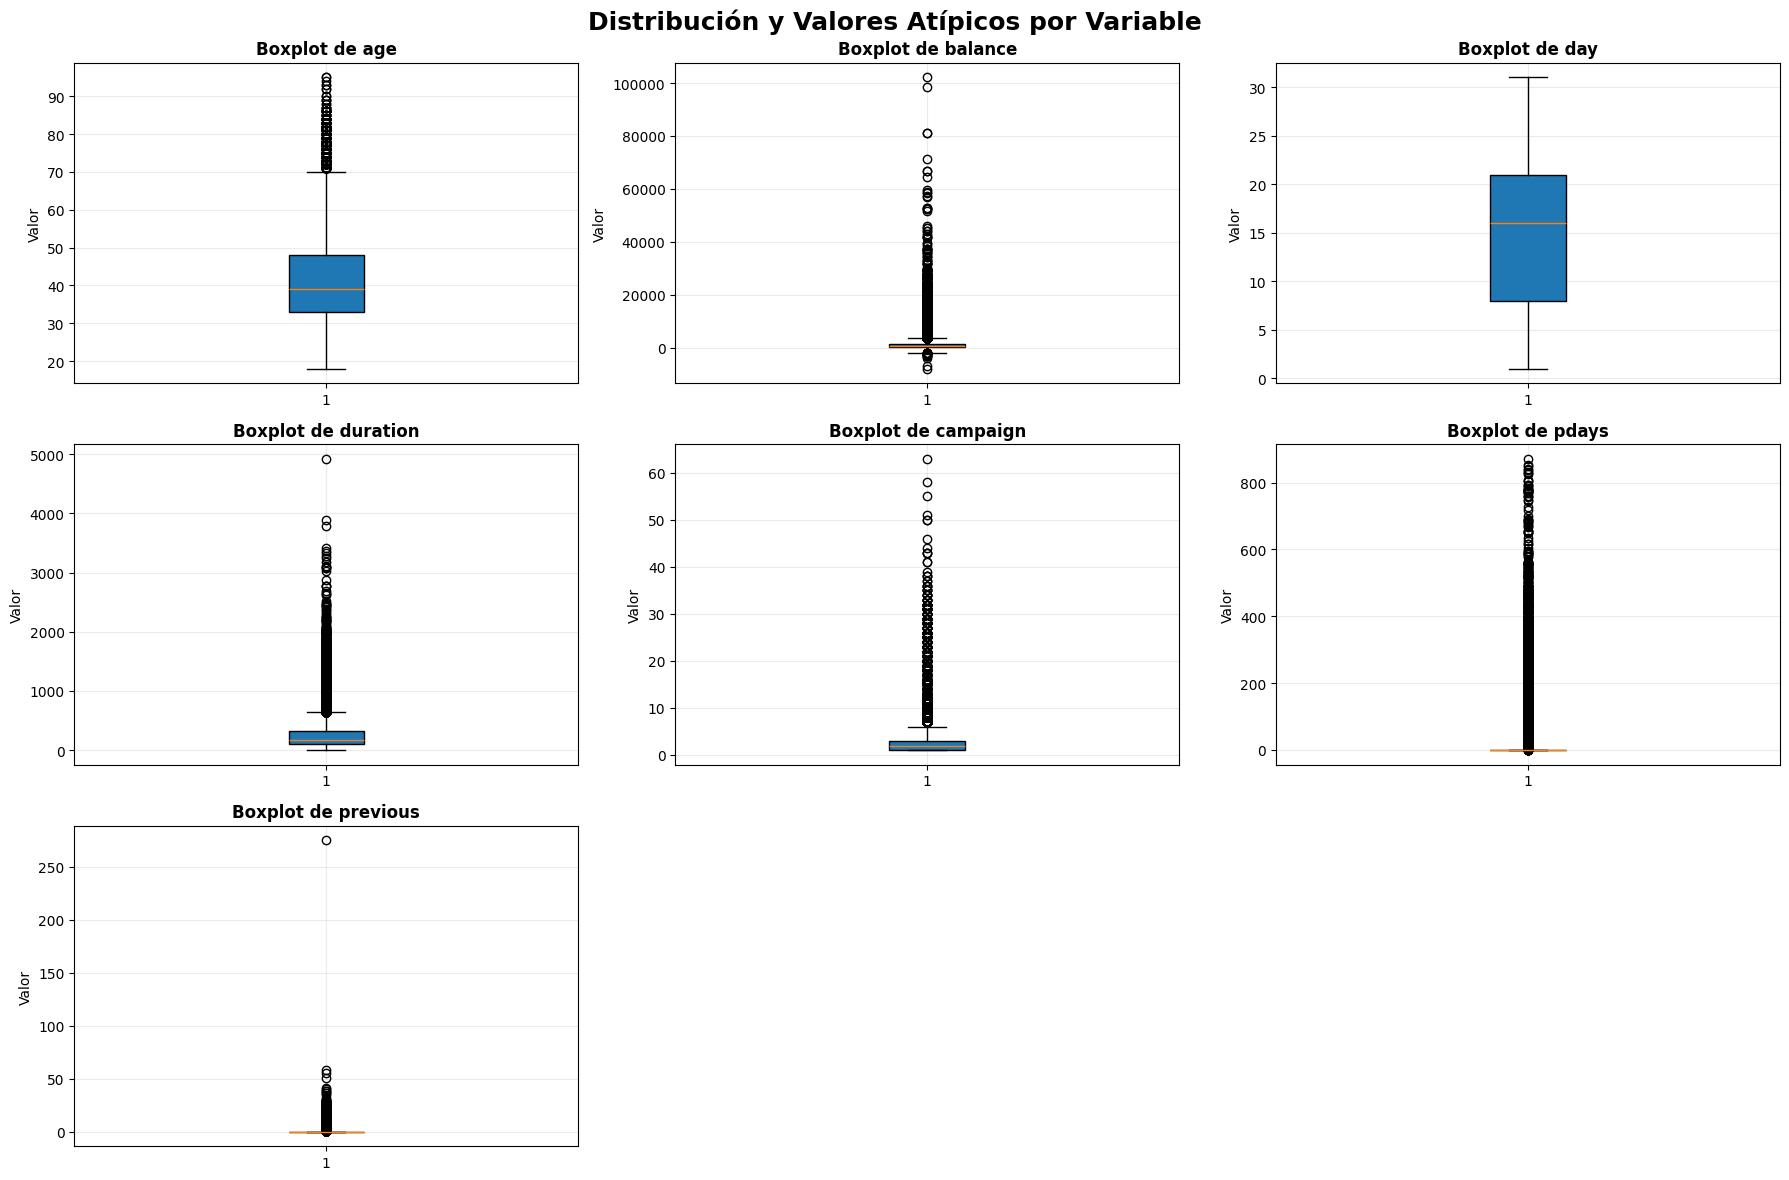

In [13]:
# Selección de atributos numéricos y conversión a estructura local de Pandas
# Selection of numerical attributes and conversion to a local Pandas structure
columnas_numericas = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

pdf_num = df01.select(columnas_numericas).toPandas()

# Configuración del lienzo y generación de diagramas de caja para evaluar dispersión y outliers
# Canvas configuration and generation of boxplots to evaluate dispersion and outliers
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    axes[i].boxplot(
        pdf_num[col].dropna(),
        vert=True,
        patch_artist=True
    )
    axes[i].set_title(
        f"Boxplot de {col}",
        fontsize=12,
        fontweight="bold"
    )
    axes[i].set_ylabel("Valor")
    axes[i].grid(alpha=0.25)

# Limpieza de los contenedores gráficos residuales que permanecieron sin datos
# Cleanup of residual plot containers that remained without data
for j in range(len(columnas_numericas), len(axes)):
    fig.delaxes(axes[j])

# Ajuste global de títulos, márgenes y renderizado final de la figura
# Global adjustment of titles, margins, and final rendering of the figure
plt.suptitle(
    "Distribución y Valores Atípicos por Variable",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Explicación del Proceso
En esta sección se detalla brevemente el procedimiento realizado en las celdas anteriores.
---
## Resumen
1. **Transformaciones Realizadas**
   - Se aplicaron ajustes a las variables predictoras.
2. **Análisis Exploratorio**
   - Se exploraron distribuciones y relaciones clave.
---
# Process Explanation
This section briefly outlines the procedure carried out in the previous cells.
---
## Summary
1. **Transformations Applied**
   - Adjustments were made to predictor variables.
2. **Exploratory Analysis**
   - Key distributions and relationships were explored.

In [14]:
# Definición del conjunto de variables numéricas base
# Definition of the base numerical variables set
colNum = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

# Selección de los atributos cuantitativos junto con el objetivo estructurado
# Selection of quantitative attributes along with the structured target
dfauxNum = df01.select(colNum + ['y'])

# Mapeo binario de la columna objetivo mediante lógica condicional
# Binary mapping of the target column using conditional logic
dfauxNum = dfauxNum.withColumn(
    'y',
    F.when(dfauxNum['y'] == 'yes', 1)
     .otherwise(0)
)

# Comprobación de la transformación en las primeras filas del DataFrame
# Transformation check on the first rows of the DataFrame
dfauxNum.show(5)

+---+-------+---+--------+--------+-----+--------+---+
|age|balance|day|duration|campaign|pdays|previous|  y|
+---+-------+---+--------+--------+-----+--------+---+
| 58|   2143|  5|     261|       1|   -1|       0|  0|
| 44|     29|  5|     151|       1|   -1|       0|  0|
| 33|      2|  5|      76|       1|   -1|       0|  0|
| 47|   1506|  5|      92|       1|   -1|       0|  0|
| 33|      1|  5|     198|       1|   -1|       0|  0|
+---+-------+---+--------+--------+-----+--------+---+
only showing top 5 rows



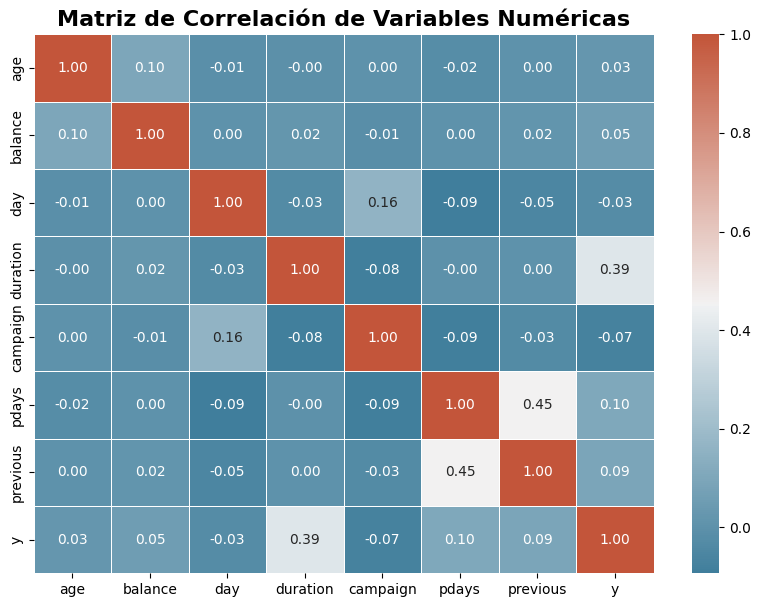

In [15]:
# Integración de variables en una estructura vectorial única para Spark ML
# Integration of variables into a single vector structure for Spark ML
ensamblador = VectorAssembler(
    inputCols=dfauxNum.columns,
    outputCol="features"
)

dfNumVector = (
    ensamblador.transform(dfauxNum).select("features")
)

# Ejecución del cálculo de coeficientes de correlación de Pearson
# Execution of the Pearson correlation coefficients calculation
matrizcorr = Correlation.corr(dfNumVector,"features","pearson").head()

# Transformación de la matriz resultante a una estructura NumPy
# Transformation of the resulting matrix into a NumPy structure
vectorcorr = matrizcorr[0].toArray()

# Construcción de la estructura DataFrame de Pandas para indexación tabular
# Construction of the Pandas DataFrame structure for tabular indexing
dfCorrelacion = pd.DataFrame(
    vectorcorr,
    columns=dfauxNum.columns,
    index=dfauxNum.columns
)

# Definición de la paleta de colores y dimensiones del contenedor gráfico
# Color palette and plot container dimensions definition
plt.figure(figsize=(10,7))

cmapJOHN = sns.diverging_palette(
    230,
    20,
    as_cmap=True
)

# Generación y renderizado del mapa de calor con anotaciones numéricas
# Generation and rendering of the heatmap with numerical annotations
sns.heatmap(
    dfCorrelacion,
    annot=True,
    fmt=".2f",
    cmap=cmapJOHN,
    linewidths=0.5
)

plt.title(
    "Matriz de Correlación de Variables Numéricas",
    fontsize=16,
    fontweight="bold"
)

plt.show()

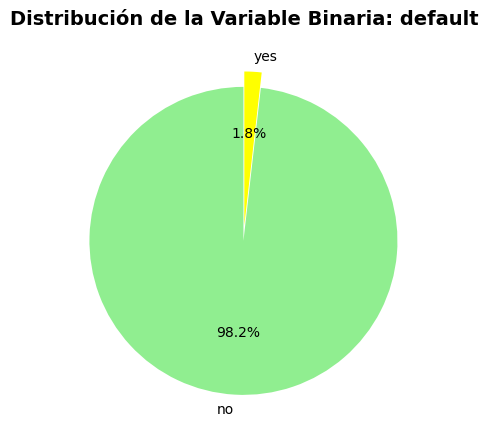

In [16]:
# Agrupación por la métrica de morosidad y conversión a estructura local de Pandas
# Grouping by the default metric and conversion to a local Pandas structure
cantBin = (
    df01
    .groupBy("default")
    .count()
    .toPandas()
)

# Definición de parámetros estéticos del gráfico de sectores (desfase y paleta)
# Aesthetic parameters definition for the pie chart (offset and palette)
explode = (0.1, 0)
colors = ['lightgreen', 'yellow']

plt.figure(figsize=(6,5))

# Renderizado del gráfico de pastel con porcentajes y orientación personalizada
# Rendering of the pie chart with percentages and customized orientation
cantBin.set_index("default")["count"].plot(
    kind='pie',explode=explode,colors=colors,autopct='%1.1f%%',startangle=90
)

plt.title(
    'Distribución de la Variable Binaria: default',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('')

plt.show()

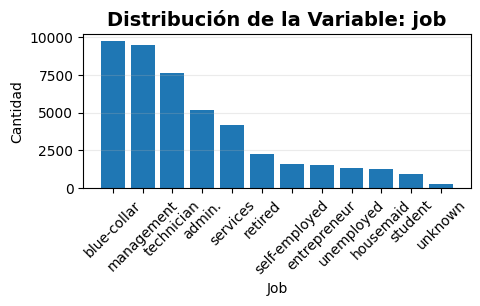

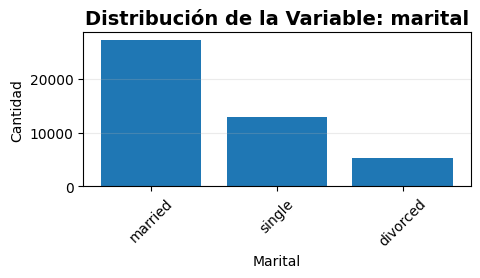

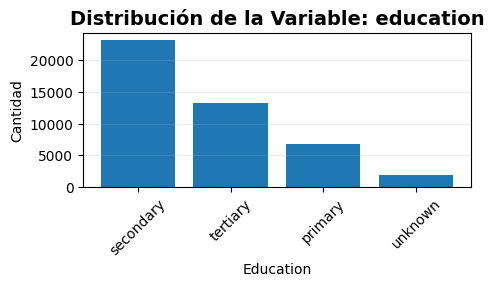

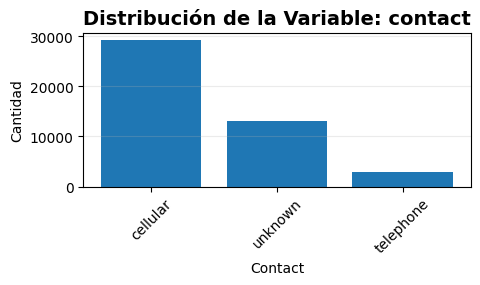

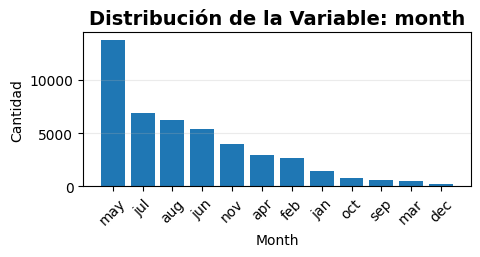

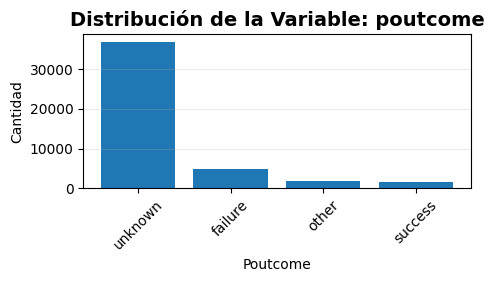

In [17]:
# Definición del conjunto de atributos categóricos multidimensionales para análisis
# Definition of the multi-dimensional categorical attributes set for analysis
variablesMulti = [
    'job',
    'marital',
    'education',
    'contact',
    'month',
    'poutcome'
]

# Procesamiento iterativo de agrupamiento, ordenamiento y renderizado para cada variable
# Iterative processing of grouping, sorting, and rendering for each variable
for variable in variablesMulti:

    # Agrupación y conteo de frecuencias por categoría convertida a estructura Pandas
    # Grouping and frequency count by category converted to Pandas structure
    cantMulti = (
        df01
        .groupBy(variable)
        .count()
        .toPandas()
    )

    # Ordenamiento de los registros de forma descendente basados en la frecuencia
    # Record sorting in descending order based on frequency
    cantMulti = cantMulti.sort_values(
        'count',
        ascending=False
    )

    # Inicialización del contenedor gráfico y dibujo del diagrama de barras
    # Graphical container initialization and bar chart plotting
    plt.figure(figsize=(5,2))

    plt.bar(
        cantMulti[variable],
        cantMulti['count']
    )

    # Configuración de las etiquetas de los ejes y formato estético del título
    # Axis labels configuration and title aesthetic formatting
    plt.xlabel(variable.capitalize())
    plt.ylabel('Cantidad')

    plt.title(
        f'Distribución de la Variable: {variable}',
        fontsize=14,
        fontweight='bold'
    )

    # Rotación de los textos en el eje horizontal y adición de la cuadrícula base
    # Horizontal axis text rotation and addition of the base grid
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.25)

    plt.show()

# Análisis de Variables Categóricas Multidimensionales
En esta sección se examinan las distribuciones y patrones de las variables categóricas.
---
## Principales Observaciones
### Variable `job`
- Predominan `blue-collar`, `management` y `technician`.
- `student` y `unknown` tienen baja frecuencia.
### Variable `marital`
- `married` es la categoría dominante.
- `divorced` tiene menor proporción.
### Variable `education`
- `secondary` y `tertiary` son las más comunes.
- `primary` y `unknown` tienen menor participación.
### Variable `contact`
- `cellular` es el canal principal.
### Variable `month`
- `may` lidera en registros.
### Variable `poutcome`
- `unknown` domina ampliamente.
---
## Observaciones Generales
1. Varias variables presentan distribuciones desbalanceadas.
2. Algunas categorías dominantes podrían influir en `y`.
3. `unknown` requiere tratamiento.
---
# Multidimensional Categorical Variable Analysis
This section examines distributions and patterns of categorical variables.
---
## Key Observations
### Variable `job`
- `blue-collar`, `management`, and `technician` dominate.
- `student` and `unknown` have low frequency.
### Variable `marital`
- `married` is the dominant category.
- `divorced` has the lowest proportion.
### Variable `education`
- `secondary` and `tertiary` are most common.
- `primary` and `unknown` have lower participation.
### Variable `contact`
- `cellular` is the main channel.
### Variable `month`
- `may` leads in records.
### Variable `poutcome`
- `unknown` dominates significantly.
---
## General Observations
1. Several variables show unbalanced distributions.
2. Some dominant categories may influence `y`.
3. `unknown` requires preprocessing.

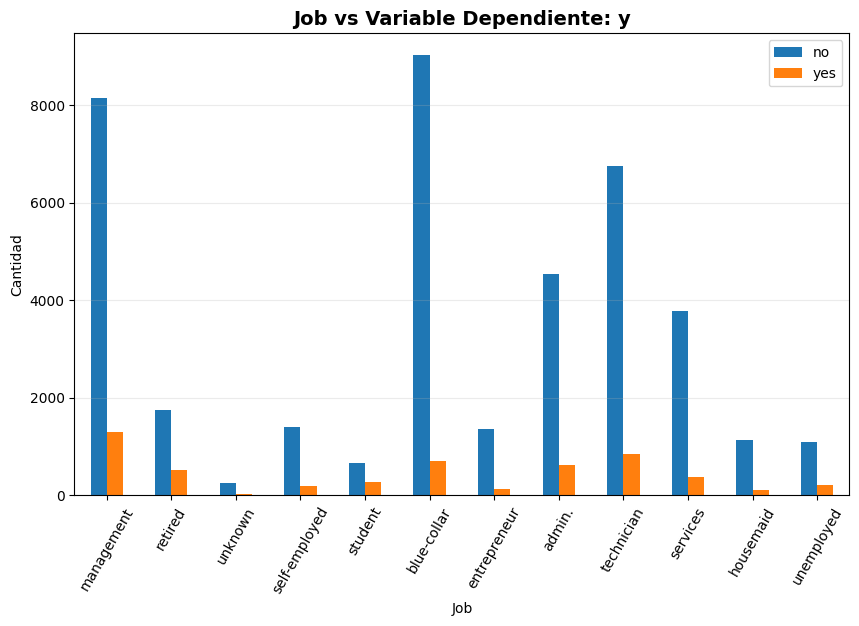

In [18]:
# Generación de la tabla de contingencia entre la ocupación y el objetivo
# Contingency table generation between occupation and target variable
crosstabJob = (
    df01
    .crosstab('job', 'y')
    .toPandas()
)

# Configuración del índice de la estructura para ajustar el formato del gráfico
# Structure index configuration to adjust plot formatting
crosstabJob = crosstabJob.set_index('job_y')

# Renderizado del gráfico de barras agrupadas y dimensionamiento del lienzo
# Grouped bar chart rendering and canvas sizing
crosstabJob.plot(
    kind='bar',
    figsize=(10,6)
)


plt.xlabel('Job')
plt.ylabel('Cantidad')

plt.title(
    'Job vs Variable Dependiente: y',
    fontsize=14,
    fontweight='bold'
)

plt.xticks(rotation=60)
plt.grid(axis='y', alpha=0.25)

plt.show()

# Relación entre `job` y `y`
En esta sección se analiza cómo las ocupaciones influyen en la variable objetivo.
---
## Principales Observaciones
1. **Predominio de Respuestas Negativas**
   - En todas las ocupaciones, `no` es la respuesta mayoritaria.
2. **Ocupaciones con Mayor Frecuencia**
   - `blue-collar`, `management` y `technician` concentran la mayoría de registros.
3. **Mayor Proporcivn de `yes` en `management` y `technician`**
   - Estas ocupaciones tienen más respuestas positivas.
4. **Menor Representatividad en Ocupaciones con Baja Frecuencia**
   - `student`, `unknown`, y `housemaid` tienen pocos registros.
5. **Relevancia Predictiva de `job`**
   - Las diferencias entre ocupaciones sugieren que `job` es clave para modelos.
---
# Relationship Between `job` and `y`
This section analyzes how occupations influence the target variable.
---
## Key Observations
1. **Predominance of Negative Responses**
   - `no` is the majority response across all occupations.
2. **Occupations with Higher Frequency**
   - `blue-collar`, `management`, and `technician` have the most records.
3. **Higher Proportion of `yes` in `management` and `technician`**
   - These occupations show more positive responses.
4. **Lower Representativeness in Low-Frequency Occupations**
   - `student`, `unknown`, and `housemaid` have fewer records.
5. **Predictive Relevance of `job`**
   - Differences among occupations suggest `job` is key for models.

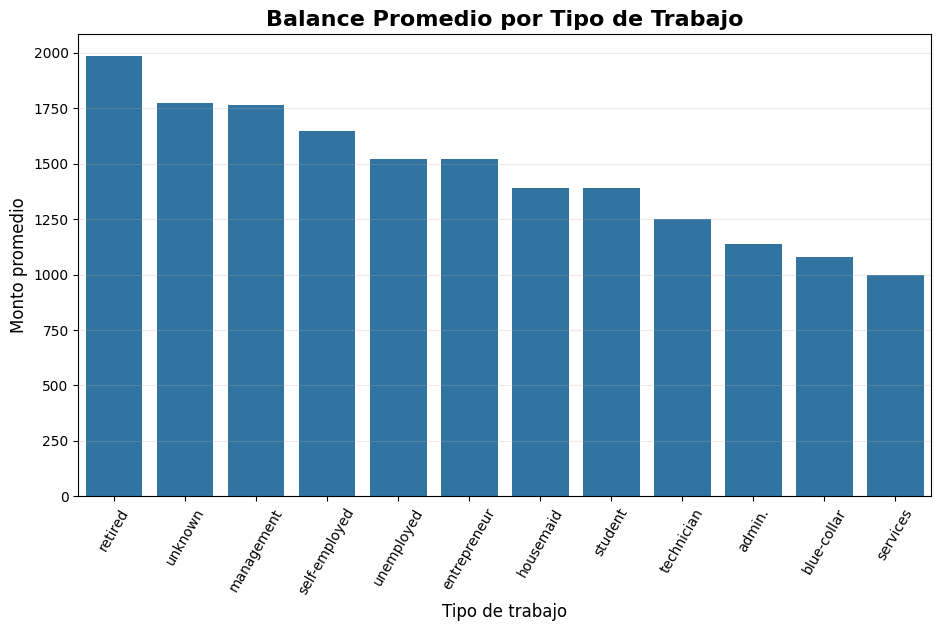

In [19]:
# Definición de estructuras de datos y cálculo de promedios agregados por ocupación
# Data structures definition and calculation of aggregate averages by occupation
nomColumnas = [
    'age', 'job', 'marital', 'education',
    'default', 'balance', 'housing',
    'loan', 'contact', 'day',
    'month', 'duration', 'campaign',
    'pdays', 'previous', 'poutcome', 'y'
]

colNum = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

# Agregación por tipo de empleo para obtener la media de los saldos financieros
# Aggregation by job type to obtain the mean of financial balances
monto_trabajo = (
    df01
    .groupBy('job')
    .agg({'balance': 'mean'})
    .toPandas()
)

# Ordenamiento descendente según el promedio calculado para mejorar la legibilidad gráfica
# Descending sorting according to the calculated average to improve graphical readability
monto_trabajo = monto_trabajo.sort_values(
    'avg(balance)',
    ascending=False
)

# Configuración del lienzo y generación del gráfico de barras de distribución comercial
# Canvas configuration and generation of the commercial distribution bar chart
plt.figure(figsize=(11,6))

sns.barplot(
    data=monto_trabajo,
    x='job',
    y='avg(balance)'
)


plt.xlabel(
    "Tipo de trabajo",
    fontsize=12
)

plt.ylabel(
    "Monto promedio",
    fontsize=12
)

plt.title(
    "Balance Promedio por Tipo de Trabajo",
    fontsize=16,
    fontweight='bold'
)

plt.xticks(rotation=60)
plt.grid(axis='y', alpha=0.25)

plt.show()

# Balance Promedio por Ocupación
En esta sección se analiza el balance promedio según el tipo de trabajo.
---
## Principales Observaciones
1. **Mayor Balance: `retired`**
   - Los clientes retirados tienen el balance promedio más alto.
2. **Balances Elevados en `management` y `self-employed`**
   - Estas ocupaciones muestran mayor capacidad económica.
3. **Balance Alto en `unknown`**
   - Clientes con ocupación desconocida tienen balances altos.
4. **Balances Bajos en Ocupaciones Operativas**
   - `services`, `blue-collar` y `admin.` tienen menores balances.
5. **Relación Ocupación-Balance**
   - `job` está relacionado con el comportamiento financiero.
---
# Average Balance by Occupation
This section analyzes the average balance by job type.
---
## Key Observations
1. **Highest Balance: `retired`**
   - Retired clients have the highest average balance.
2. **High Balances in `management` and `self-employed`**
   - These occupations show greater economic capacity.
3. **High Balance in `unknown`**
   - Clients with unknown occupation have high balances.
4. **Lower Balances in Operational Occupations**
   - `services`, `blue-collar`, and `admin.` have lower balances.
5. **Occupation-Balance Relationship**
   - `job` is related to financial behavior.

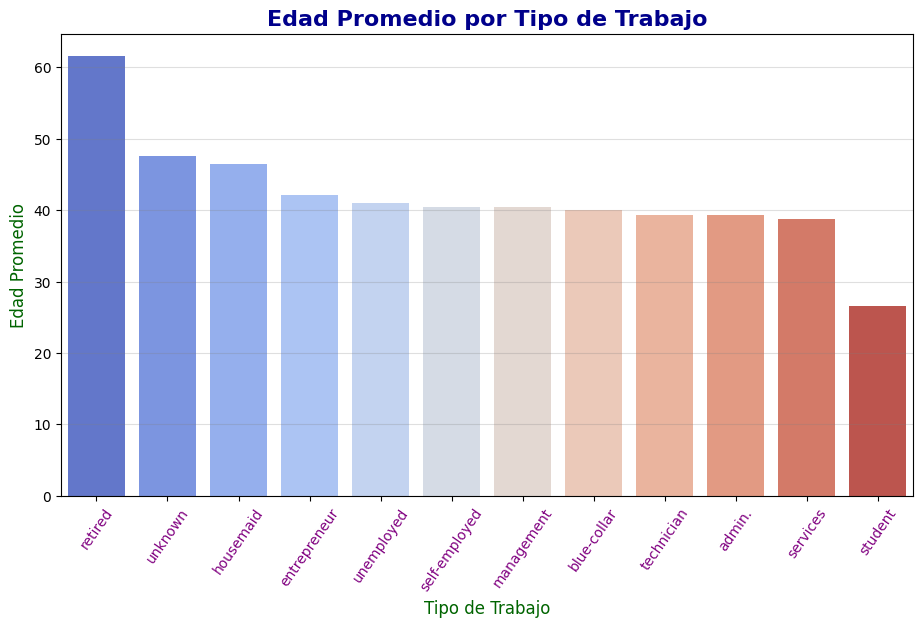

In [20]:
# Agrupación y cálculo de la edad promedio por categoría ocupacional
# Grouping and average age calculation by occupational category
edad_trabajo = (
    df01
    .groupBy("job")
    .agg({'age': 'mean'})
    .toPandas()
)

# Ordenamiento de los registros de manera descendente según la media etaria
# Record sorting in descending order based on the age mean
edad_trabajo = edad_trabajo.sort_values(
    'avg(age)',
    ascending=False
)

# Configuración del lienzo y renderizado del diagrama de barras con mapa de color
# Canvas configuration and bar chart rendering with color mapping
plt.figure(figsize=(11, 6))

sns.barplot(
    data=edad_trabajo,
    x='job',
    y='avg(age)',
    hue='job',
    palette="coolwarm",
    legend=False
)


plt.title(
    "Edad Promedio por Tipo de Trabajo",
    fontsize=16,
    fontweight='bold',
    color="darkblue"
)

plt.xlabel(
    "Tipo de Trabajo",
    fontsize=12,
    color="darkgreen"
)

plt.ylabel(
    "Edad Promedio",
    fontsize=12,
    color="darkgreen"
)

# Rotación de los identificadores del eje horizontal y adición de la cuadrícula base
# Horizontal axis identifiers rotation and base grid addition
plt.xticks(rotation=55, fontsize=10, color="purple")
plt.grid(axis='y', alpha=0.25, color="gray")

plt.show()

# Análisis de Edad Promedio por Ocupación
En este análisis, se examina la relación entre las categorías ocupacionales y la edad promedio de los clientes.
---
## Principales Observaciones
1. **Mayor Edad Promedio: `retired`**
   - Los clientes retirados tienen la edad promedio más alta, lo cual refleja su estabilidad financiera y experiencia.
2. **Menor Edad Promedio: `student`**
   - Los estudiantes son el grupo más joven, con una diferencia significativa respecto a otras ocupaciones.
3. **Edades Similares en Ocupaciones Activas**
   - Categorías como `management`, `technician`, `admin.`, `blue-collar` y `services` presentan promedios cercanos, entre 39 y 41 años.
4. **Edades Elevadas en `housemaid` y `unknown`**
   - Estas categorías muestran edades superiores a la media, indicando perfiles demográficos específicos.
5. **Relación Ocupación-Edad**
   - La ocupación está estrechamente vinculada con diferencias demográficas, haciendo de `job` una variable clave para análisis predictivos.
---
# Average Age Analysis by Occupation
This analysis explores the relationship between occupational categories and the average age of clients.
---
## Key Observations
1. **Highest Average Age: `retired`**
   - Retired clients exhibit the highest average age, reflecting their financial stability and experience.
2. **Lowest Average Age: `student`**
   - Students represent the youngest group, with a significant gap compared to other occupations.
3. **Similar Ages in Active Occupations**
   - Categories like `management`, `technician`, `admin.`, `blue-collar`, and `services` show close averages, ranging from 39 to 41 years.
4. **Higher Ages in `housemaid` and `unknown`**
   - These groups display above-average ages, indicating specific demographic profiles.
5. **Occupation-Age Relationship**
   - Occupation is closely linked to demographic differences, making `job` a key variable for predictive analysis.

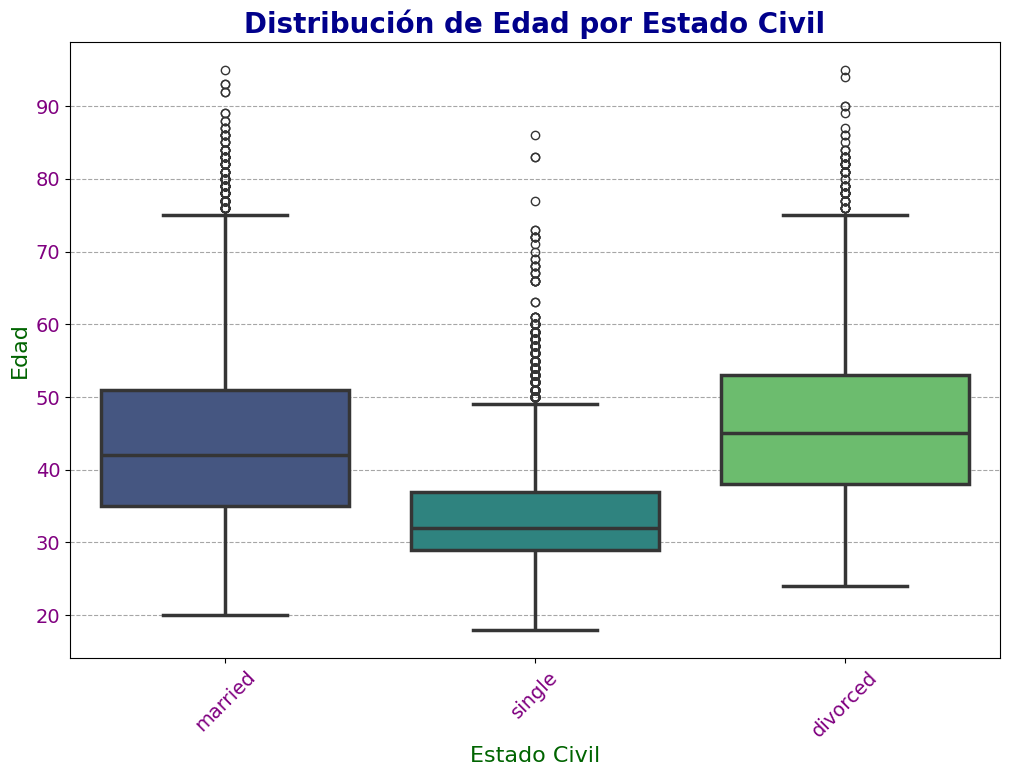

In [21]:
# Selección de atributos demográficos y migración a estructura local de Pandas
# Selection of demographic attributes and migration to a local Pandas structure
df_box2 = (
    df01
    .select("age", "marital")
    .toPandas()
)

# Configuración dimensional del contenedor gráfico
# Dimensional configuration of the plot container
plt.figure(figsize=(12, 8))


sns.boxplot(
    data=df_box2,
    x="marital",
    y="age",
    hue="marital",
    palette="viridis",
    linewidth=2.5,
    legend=False
)


plt.title(
    "Distribución de Edad por Estado Civil",
    fontsize=20,
    fontweight='bold',
    color="darkblue"
)

plt.xlabel(
    "Estado Civil",
    fontsize=16,
    color="darkgreen"
)

plt.ylabel(
    "Edad",
    fontsize=16,
    color="darkgreen"
)


plt.xticks(rotation=45, fontsize=14, color="purple")
plt.yticks(fontsize=14, color="purple")

# Adición de una malla estructural segmentada en el eje vertical
# Addition of a segmented structural mesh on the vertical axis
plt.grid(axis='y', linestyle='--', alpha=0.7, color="gray")


plt.show()

### Explicación del Gráfico
- Este gráfico muestra la relación entre la edad y el estado civil de los clientes.
- Destaca la mediana de edad, la dispersión de los datos, el rango intercuartílico (RIC) y los valores atípicos.
- Este análisis es útil para identificar patrones en los datos demográficos.

- This graph shows the relationship between age and marital status of clients.
- It highlights the median age, data dispersion, interquartile range (IQR), and outliers.
- This analysis is useful for identifying patterns in demographic data.

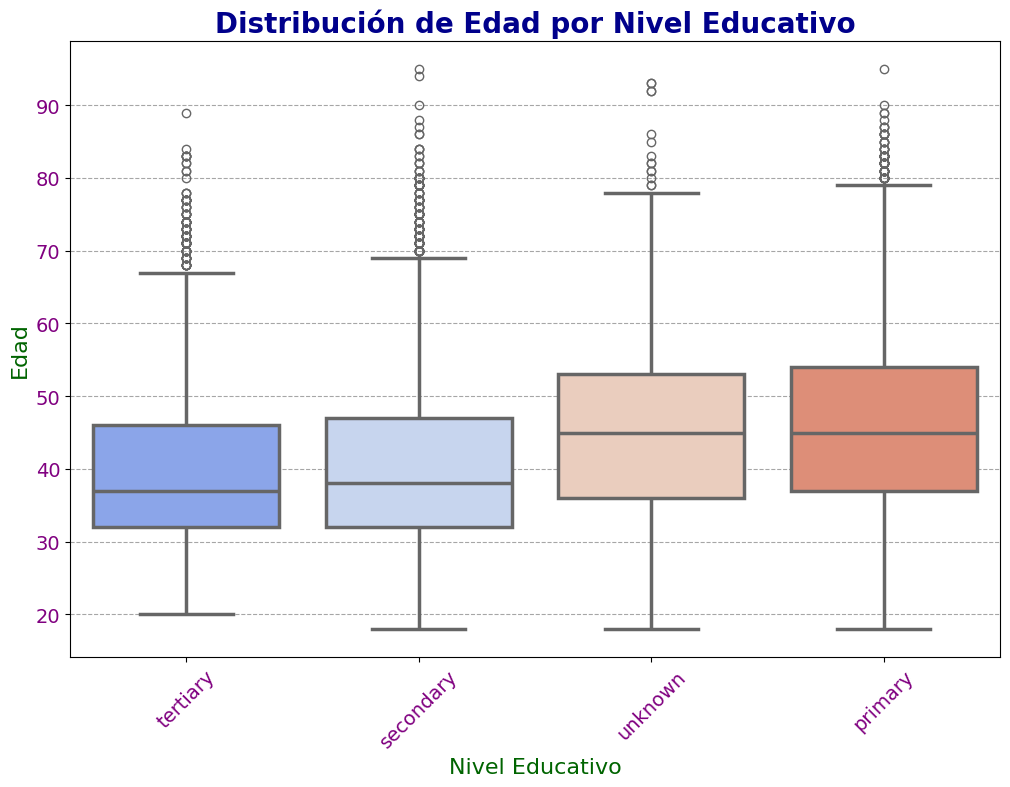

In [22]:
# Selección de atributos de interés y conversión a estructura local de Pandas
# Selection of attributes of interest and conversion to a local Pandas structure
df_box1 = (
    df01
    .select("age", "education")
    .toPandas()
)

# Configuración de las dimensiones del lienzo del gráfico
# Configuration of the plot canvas dimensions
plt.figure(figsize=(12, 8))

# Generación del diagrama de caja multifactorial con mapeo de color y estilización de líneas
# Generation of the multi-factor boxplot with color mapping and line styling
sns.boxplot(
    data=df_box1,
    x="education",
    y="age",
    hue="education",
    palette="coolwarm",
    linewidth=2.5,
    legend=False
)


plt.title(
    "Distribución de Edad por Nivel Educativo",
    fontsize=20,
    fontweight='bold',
    color="darkblue"
)

plt.xlabel(
    "Nivel Educativo",
    fontsize=16,
    color="darkgreen"
)

plt.ylabel(
    "Edad",
    fontsize=16,
    color="darkgreen"
)

# Ajuste de escala, rotación de etiquetas estructurales y adición de la malla de fondo
# Scale adjustment, structural labels rotation, and addition of the background mesh
plt.xticks(rotation=45, fontsize=14, color="purple")
plt.yticks(fontsize=14, color="purple")
plt.grid(axis='y', linestyle='--', alpha=0.7, color="gray")


plt.show()

### Explicación del Gráfico

El gráfico muestra la distribución de edades según el nivel educativo de los clientes. Utilizando un boxplot, se pueden observar:
- La mediana de las edades para cada nivel educativo.
- La dispersión de los datos.
- El rango intercuartólico (IQR).
- Valores atípicos que se encuentran fuera del rango esperado.

The graph illustrates the age distribution based on the educational level of clients. Using a boxplot, it highlights:
- The median age for each educational level.
- The data dispersion.
- The interquartile range (IQR).
- Outliers that fall outside the expected range.

### Calidad de los datos

---

### Data Quality

In [23]:
# Evaluación iterativa de la calidad de datos mediante el conteo de registros nulos por columna
# Iterative evaluation of data quality by counting null records per column
for columna in df01.columns:
    cantNulos = df01.where(F.col(columna).isNull()).count()
    print(f"'{columna}' : {cantNulos} valores nulos")

'age' : 0 valores nulos
'job' : 0 valores nulos
'marital' : 0 valores nulos
'education' : 0 valores nulos
'default' : 0 valores nulos
'balance' : 0 valores nulos
'housing' : 0 valores nulos
'loan' : 0 valores nulos
'contact' : 0 valores nulos
'day' : 0 valores nulos
'month' : 0 valores nulos
'duration' : 0 valores nulos
'campaign' : 0 valores nulos
'pdays' : 0 valores nulos
'previous' : 0 valores nulos
'poutcome' : 0 valores nulos
'y' : 0 valores nulos


### Preparación de los datos

---

### Data Preparation

In [24]:
# Filtrado y conteo de registros donde el cliente no registra contactos previos
# Filtering and counting of records where the client has no previous contact history
noPDAYS = df01.filter(F.col('pdays') == -1).count()

# Obtención del volumen total de registros para el cálculo proporcional
# Obtaining the total volume of records for proportional calculation
total = df01.count()

# Determinación del impacto porcentual de la condición evaluada sobre el total
# Determination of the percentage impact of the evaluated condition over the total
porcNoPDAYS = (noPDAYS/total)*100

print(f"Porcentaje de clientes no contactados con anterioridad (variable PDAYS=-1): {porcNoPDAYS:.2f}%")

Porcentaje de clientes no contactados con anterioridad (variable PDAYS=-1): 81.74%


In [25]:
# Agrupación por cantidad de contactos previos y ordenamiento descendente de las categorías
# Grouping by amount of previous contacts and descending sorting of the categories
df01.groupBy("previous").count().sort("previous", ascending=False).show()

+--------+-----+
|previous|count|
+--------+-----+
|     275|    1|
|      58|    1|
|      55|    1|
|      51|    1|
|      41|    1|
|      40|    1|
|      38|    2|
|      37|    2|
|      35|    1|
|      32|    1|
|      30|    3|
|      29|    4|
|      28|    2|
|      27|    5|
|      26|    2|
|      25|    4|
|      24|    5|
|      23|    8|
|      22|    6|
|      21|    4|
+--------+-----+
only showing top 20 rows



In [26]:
# Establecimiento del umbral superior para depuración de registros atípicos
# Establishment of the upper threshold for outlier record filtering
limitePrevio = 30

# Cuantificación de registros cuya frecuencia de contactos supera el límite definido
# Quantification of records whose contact frequency exceeds the defined limit
cantPrevioLim = df01.filter(F.col('previous') > limitePrevio).count()
print(f"Cantidad de registros superiores a {limitePrevio} contactos realizados: {cantPrevioLim}")

Cantidad de registros superiores a 30 contactos realizados: 12


In [27]:
# Filtrado exclusorio para remover registros con valores atípicos en contactos previos
# Exclusionary filtering to remove records with outliers in previous contacts
df02 = df01.filter(F.col('previous')<=30)

# Remoción estructural de la columna de días transcurridos del DataFrame
# Structural removal of the elapsed days column from the DataFrame
df03 = df02.drop('pdays')

### Formato de Datos

La función `sample` permite equilibrar el conjunto de datos para optimizar el entrenamiento del modelo. En este escenario, incrementa los casos afirmativos duplicándolos mediante un muestreo aleatorio regulado por una semilla.

Información sobre `sample` se puede consultar [aquí](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html).

---

### Data Formatting

The `sample` function balances the dataset to optimize model training. In this scenario, it increases the positive cases by duplicating them through random sampling controlled by a seed.

Information about `sample` can be found [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html).

In [28]:
# Segmentación del conjunto de datos en clases mayoritaria y minoritaria
# Dataset segmentation into majority and minority classes
dfMayorDependiente = df03.filter(df03['y'] == 'no')
dfMenorDependiente = df03.filter(df03['y'] == 'yes')

# Cuantificación del volumen de registros pertenecientes a la clase predominante
# Quantification of the volume of records belonging to the predominant class
cantMayor = dfMayorDependiente.count()

# Ejecución de sobremuestreo con reemplazo sobre la clase minoritaria para equilibrar la distribución
# Execution of oversampling with replacement on the minority class to balance the distribution
dfOverSampledMinor = dfMenorDependiente.sample(True, cantMayor/dfMenorDependiente.count(), seed=42)

# Unificación estructural de los conjuntos balanceados en un único DataFrame resultante
# Structural unification of the balanced sets into a single resulting DataFrame
df04 = dfMayorDependiente.union(dfOverSampledMinor)

# Recuperación del listado de columnas del DataFrame balanceado
# Retrieval of the columns list from the balanced DataFrame
df04.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'previous',
 'poutcome',
 'y']

In [29]:
print(f"El df04 queda (luego del oversampling) = {df04.count()}")

El df04 queda (luego del oversampling) = 80201


In [30]:
# Cuantificación del volumen total de registros del nuevo conjunto unificado
# Quantification of the total volume of records in the new unified dataset
totalNw = df04.count()

# Agrupación y conteo absoluto de frecuencias por categoría de la variable objetivo
# Grouping and absolute frequency count by category of the target variable
dfaux = df04.groupBy('y').count()

# Cálculo y adición de la columna proporcional para verificar la equidad de las clases
# Calculation and addition of the proportional column to verify class equity
dfBalance = dfaux.withColumn("Porcentaje", dfaux["count"]*100/totalNw)

# Despliegue en consola de la tabla resultante con las métricas de balanceo
# Console display of the resulting table with the balancing metrics
dfBalance.show()

+---+-----+-----------------+
|  y|count|       Porcentaje|
+---+-----+-----------------+
|yes|40289|50.23503447587935|
| no|39912|49.76496552412065|
+---+-----+-----------------+



In [31]:
print(f"Cantidad de registros de DF01 = {df01.count()}")
print(f"Cantidad de registros de DF04 = {df04.count()}")

Cantidad de registros de DF01 = 45211
Cantidad de registros de DF04 = 80201


## Codificación para la creación de vector ensamblador para las variables categóricas ("features" "target")

### ¿Para qué sirve StringIndexer?
`StringIndexer` es una herramienta de PySpark que transforma columnas de texto categórico en índices numéricos secuenciales. Esta conversión es indispensable debido a que los algoritmos de Machine Learning requieren entradas numéricas para operar. El indexador analiza los valores únicos de la columna objetivo y asigna a cada uno un número entero, guardando el resultado en una nueva columna.

### ¿Para qué sirve OneHotEncoder?  
`OneHotEncoder` es un componente de PySpark que convierte los índices numéricos de las variables categóricas en vectores binarios (vectores "one-hot"). Este enfoque es ideal para datos nominales que carecen de un orden lógico, ya que genera una representación geométrica en la que todas las categorías son tratadas de forma equivalente, optimizando el rendimiento de los modelos predictivos.

---

## Coding for creating the VectorAssembler for categorical variables ("features" "target")

### What is StringIndexer used for?
`StringIndexer` is a PySpark tool that transforms categorical text columns into sequential numerical indices. This conversion is essential because Machine Learning algorithms require numerical inputs to operate. The indexer analyzes the unique values of the target column and assigns each one an integer, saving the result into a new column.

### What is OneHotEncoder used for?  
`OneHotEncoder` is a PySpark component that converts numerical indices from categorical variables into binary vectors ("one-hot" vectors). This approach is ideal for nominal data lacking a logical order, as it creates a geometric representation where all categories are treated equally, optimizing the performance of predictive models.

In [32]:
# Definición del listado de atributos categóricos para el flujo de transformación
# Definition of the categorical attributes list for the transformation workflow
CATEG_col = ['job', 'marital', 'education', 'default', 'month', 'housing', 'loan', 'contact', 'poutcome']

# Inicialización de la estructura contenedora de las fases del Pipeline
# Initialization of the pipeline stages container structure
etapas = []

# Construcción iterativa de los componentes de indexación y codificación por columna
# Iterative construction of indexing and encoding components per column
for colCategorie in CATEG_col:
    
    # Configuración del estimador para asociar etiquetas de texto con índices numéricos
    # Configuration of the estimator to map text labels to numerical indices
    indexer = StringIndexer(inputCol=colCategorie, outputCol=colCategorie + 'x')
    
    # Configuración del transformador para mapear índices hacia vectores dispersos binarios
    # Configuration of the transformer to map indices to binary sparse vectors
    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[colCategorie + '_oneHot'])
    
    # Consolidación secuencial de los objetos dentro del arreglo de ejecución
    # Sequential consolidation of objects within the execution array
    etapas += [indexer, encoder]

In [33]:
etapas

[StringIndexer_d62edf0d5464,
 OneHotEncoder_75867a27d8bc,
 StringIndexer_9095aa1a6c01,
 OneHotEncoder_d095c90833df,
 StringIndexer_4d81418d71e0,
 OneHotEncoder_67c286a86fac,
 StringIndexer_e034644a697e,
 OneHotEncoder_292a0aebfe10,
 StringIndexer_fd1ea2e2d4ac,
 OneHotEncoder_79e2675e86bb,
 StringIndexer_16fcdee13f2d,
 OneHotEncoder_ab3b2efcbf86,
 StringIndexer_340a54059b21,
 OneHotEncoder_8f22dd9e2c7a,
 StringIndexer_1c096067035b,
 OneHotEncoder_d500797648b8,
 StringIndexer_a3fd40cbbf6b,
 OneHotEncoder_154ec157d900]

In [34]:
# Configuración del indexador binario ordenado alfabéticamente para la etiqueta objetivo
# Configuration of the alphabetically sorted binary indexer for the target label
etiqueta = StringIndexer(inputCol='y', outputCol='label', stringOrderType='alphabetAsc')

# Adición del componente de indexación al listado secuencial de etapas del Pipeline
# Addition of the indexing component to the sequential list of Pipeline stages
etapas += [etiqueta]

In [35]:
etapas

[StringIndexer_d62edf0d5464,
 OneHotEncoder_75867a27d8bc,
 StringIndexer_9095aa1a6c01,
 OneHotEncoder_d095c90833df,
 StringIndexer_4d81418d71e0,
 OneHotEncoder_67c286a86fac,
 StringIndexer_e034644a697e,
 OneHotEncoder_292a0aebfe10,
 StringIndexer_fd1ea2e2d4ac,
 OneHotEncoder_79e2675e86bb,
 StringIndexer_16fcdee13f2d,
 OneHotEncoder_ab3b2efcbf86,
 StringIndexer_340a54059b21,
 OneHotEncoder_8f22dd9e2c7a,
 StringIndexer_1c096067035b,
 OneHotEncoder_d500797648b8,
 StringIndexer_a3fd40cbbf6b,
 OneHotEncoder_154ec157d900,
 StringIndexer_fd91e7d4143a]

In [36]:
# Definición del conjunto de atributos cuantitativos que se preservarán en el modelo
# Definition of the quantitative attributes set to be preserved in the model
NUMER_col  = ['age', 'balance', 'duration', 'day', 'campaign', 'previous']

# Consolidación de los vectores binarios intermedios y las variables continuas
# Consolidation of intermediate binary vectors and continuous variables
entradaEnsamblada = [c + '_oneHot' for c in CATEG_col] + NUMER_col

# Inspección del listado integrado de componentes estructurales para el ensamblador
# Inspection of the integrated list of structural components for the assembler
entradaEnsamblada

['job_oneHot',
 'marital_oneHot',
 'education_oneHot',
 'default_oneHot',
 'month_oneHot',
 'housing_oneHot',
 'loan_oneHot',
 'contact_oneHot',
 'poutcome_oneHot',
 'age',
 'balance',
 'duration',
 'day',
 'campaign',
 'previous']

#### 1. VectorAssembler
Esta herramienta agrupa múltiples columnas de un DataFrame en una sola columna de tipo vector. Es un paso fundamental en los flujos de trabajo de Machine Learning, ya que unifica tanto los atributos originales como los procesados por otros transformadores. De este modo, se genera la estructura de datos unificada requerida para el entrenamiento de algoritmos como árboles de decisión o regresión logística.

#### 2. Pipeline
Estructura orientada a organizar y automatizar el flujo de trabajo mediante una secuencia ordenada de etapas (clasificadas en *Estimators* o *Transformers*).

Al ejecutar el método `Pipeline.fit()`, los componentes se procesan de la siguiente manera:
* **Estimadores:** Aplican el método `fit()` sobre los datos para generar un modelo adaptado. Este modelo, transformado ahora en un *Transformer*, procesa el conjunto de datos para la etapa posterior.
* **Transformadores:** Ejecutan el método `transform()` directamente para estructurar los datos que recibirá el siguiente eslabón.

El resultado final de este entrenamiento es un `PipelineModel`, un objeto compuesto por los modelos ajustados y los transformadores correspondientes. En caso de que la secuencia de etapas esté vacía, el Pipeline opera simplemente como un transformador de identidad.

---

#### 1. VectorAssembler
This tool aggregates multiple DataFrame columns into a single vector column. It is a fundamental step in Machine Learning workflows, as it unifies both raw attributes and features generated by other transformers. This generates the unified data structure required to train algorithms such as decision trees or logistic regression.

#### 2. Pipeline
A framework designed to organize and automate workflow execution through an ordered sequence of stages (classified as either *Estimators* or *Transformers*).

When the `Pipeline.fit()` method is triggered, components are processed as follows:
* **Estimators:** Execute the `fit()` method on the data to generate a fitted model. This model, now acting as a *Transformer*, processes the dataset for the subsequent stage.
* **Transformers:** Run the `transform()` method directly to format the data that the next link in the chain will receive.

The final output of this training process is a `PipelineModel`, an object composed of the fitted models and corresponding transformers. If the stage sequence is empty, the Pipeline operates simply as an identity transformer.

In [37]:
# Configuración del ensamblador para consolidar las columnas en un único vector de características
# Configuration of the assembler to consolidate columns into a single features vector
VectorEnsamblado = VectorAssembler(inputCols=entradaEnsamblada, outputCol='features')

# Incorporación del transformador vectorizador a la secuencia final de componentes
# Incorporation of the vectorizer transformer into the final sequence of components
etapas += [VectorEnsamblado]

# Inspección del arreglo definitivo con todas las fases ordenadas para el Pipeline
# Inspection of the definitive array with all ordered stages for the Pipeline
etapas

[StringIndexer_d62edf0d5464,
 OneHotEncoder_75867a27d8bc,
 StringIndexer_9095aa1a6c01,
 OneHotEncoder_d095c90833df,
 StringIndexer_4d81418d71e0,
 OneHotEncoder_67c286a86fac,
 StringIndexer_e034644a697e,
 OneHotEncoder_292a0aebfe10,
 StringIndexer_fd1ea2e2d4ac,
 OneHotEncoder_79e2675e86bb,
 StringIndexer_16fcdee13f2d,
 OneHotEncoder_ab3b2efcbf86,
 StringIndexer_340a54059b21,
 OneHotEncoder_8f22dd9e2c7a,
 StringIndexer_1c096067035b,
 OneHotEncoder_d500797648b8,
 StringIndexer_a3fd40cbbf6b,
 OneHotEncoder_154ec157d900,
 StringIndexer_fd91e7d4143a,
 VectorAssembler_a588974edd38]

In [38]:
# Verificación preventiva y remoción de la columna estructurada en caso de existencia previa
# Preventive verification and removal of the structured column in case of prior existence
#if 'features' in df04.columns:
#    df04 = df04.drop('features')

# Inicialización y ajuste del Pipeline con la secuencia de etapas configuradas
# Pipeline initialization and fitting with the sequence of configured stages
pipeline = Pipeline(stages=etapas)
pipelineModel = pipeline.fit(df04)

# Persistencia en disco del modelo del Pipeline para su reutilización en entornos de streaming
# Disk persistence of the Pipeline model for reuse in streaming environments
pipelineModel.write().overwrite().save(path='modeloPipeline')

# Aplicación de las transformaciones secuenciales sobre el conjunto de datos integrado
# Application of sequential transformations on the integrated dataset
modelo = pipelineModel.transform(df04)

modelo.printSchema()
modelo.show(5)

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)
 |-- jobx: double (nullable = false)
 |-- job_oneHot: vector (nullable = true)
 |-- maritalx: double (nullable = false)
 |-- marital_oneHot: vector (nullable = true)
 |-- educationx: double (nullable = false)
 |-- education_oneHot: vector (nullable = true)
 |-- defaultx: double (nullable = false)
 |-- default_oneHot: vector (nullable = true)
 |-- monthx: double (nullable = false)

In [39]:
# Construcción del conjunto estructurado definitivo aislando etiquetas y vectores
# Construction of the definitive structured dataset isolating labels and vectors
df05 = modelo.select("label", "features")

# Inspección rápida y almacenamiento del conteo total para mitigar re-ejecuciones costosas
# Quick inspection and storage of the total count to mitigate costly re-executions
print("df05 schema:")
df05.printSchema()
cnt = df05.count()
print("df05 count:", cnt)
df05.show(5)

# Resolución de la ruta absoluta para mitigar ambigüedades en el sistema de archivos
# Resolution of the absolute path to mitigate ambiguities in the file system
out_path = os.path.abspath("/Almacen/output.parquet")
print("Writing to:", out_path)

# Validación estructural del volumen de registros previo a la persistencia en disco
# Structural validation of record volume prior to disk persistence
if cnt > 0:
    # Coalescencia a partición única y serialización en formato Parquet comprimido con Snappy
    # Coalescence to a single partition and serialization in Parquet format compressed with Snappy
    df05.coalesce(1).write.mode("overwrite").option("compression", "snappy").parquet(out_path)
else:
    raise ValueError("df05 está vacío — revisar los pasos anteriores que generan df05")

# Rastreo recursivo de bloques binarios fragmentados dentro del directorio de salida
# Recursive tracking of fragmented binary blocks within the output directory
parts = glob.glob(os.path.join(out_path, "**", "part-*.parquet"), recursive=True)
print("Found part files:", parts)

# Control de excepciones para la verificación de la persistencia física del DataFrame
# Exception handling for checking the physical persistence of the DataFrame
if not parts:
    print("Contenido de la carpeta:", sorted(os.listdir(out_path)))
    raise RuntimeError("No se encontraron archivos 'part-*.parquet' dentro de output.parquet. " +
                       "Posibles causas: escritura en otra ubicación, permisos, o fallo en la etapa de ejecución.")
else:
    # Carga dirigida del componente binario indexado para eludir fallos latentes de metadatos
    # Targeted loading of the indexed binary component to bypass latent metadata failures
    part_to_read = parts[0]
    print("Reading parquet part:", part_to_read)
    df06 = sparkMunoz.read.parquet(part_to_read)
    df06.printSchema()
    df06.show(5)

df05 schema:
root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)

df05 count: 80201
+-----+--------------------+
|label|            features|
+-----+--------------------+
|  0.0|(41,[0,11,14,16,1...|
|  0.0|(41,[2,12,13,16,1...|
|  0.0|(41,[9,11,13,16,1...|
|  0.0|(41,[1,11,16,17,2...|
|  0.0|(41,[12,16,17,28,...|
+-----+--------------------+
only showing top 5 rows

Writing to: /Almacen/output.parquet


Found part files: ['/Almacen/output.parquet/part-00000-825455c0-7893-4fa4-a569-5063c324f12a-c000.snappy.parquet']
Reading parquet part: /Almacen/output.parquet/part-00000-825455c0-7893-4fa4-a569-5063c324f12a-c000.snappy.parquet
root
 |-- label: double (nullable = true)
 |-- features: vector (nullable = true)

+-----+--------------------+
|label|            features|
+-----+--------------------+
|  0.0|(41,[0,11,14,16,1...|
|  0.0|(41,[2,12,13,16,1...|
|  0.0|(41,[9,11,13,16,1...|
|  0.0|(41,[1,11,16,17,2...|
|  0.0|(41,[12,16,17,28,...|
+-----+--------------------+
only showing top 5 rows



### Modelización: Construcción y Evaluación de Modelos

El proceso de modelado se estructura en las siguientes fases clave:

* **División del Conjunto de Datos:** Segmentación de la información reservando un 80% para la fase de entrenamiento (*Training*) y un 20% para la fase de validación (*Testing*).
* **Control de Balanceo:** Verificación y ajuste de la distribución de clases dentro del conjunto de entrenamiento para mitigar sesgos en los algoritmos.
* **Algoritmos de Clasificación a Evaluar:**
    * Regresión Logística (*Logistic Regression*)
    * Bosques Aleatorios (*Random Forest*)
    * Árboles de Decisión (*Decision Tree*)
    * Árboles de Decisión con Gradiente Mejorado (*Gradient Boosted Tree - GBT*)
    * Máquinas de Vectores de Soporte (*Support Vector Machine - SVM*)

#### Criterios y Métricas de Evaluación
Para medir el desempeño de cada modelo, se analizan los resultados a través de las siguientes métricas basadas en la API de PySpark ([Documentación Oficial](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.mllib.evaluation.MulticlassMetrics.html)):

| Métrica | Descripción |
| :--- | :--- |
| **Matriz de Confusión** | Estructura matricial $C$ donde cada celda $C(i, j)$ representa la cantidad de observaciones de la clase real $i$ que fueron clasificadas en la categoría $j$. En un entorno binario, mapea con exactitud los verdaderos negativos $C(0,0)$, falsos negativos $C(1,0)$, verdaderos positivos $C(1,1)$ y falsos positivos $C(0,1)$. |
| **Exactitud (*Accuracy*)** | Proporción global de predicciones correctas frente al total de casos evaluados por el sistema; define la tasa general de aciertos. |
| **Precisión (*Precision*)** | Fracción de predicciones positivas que resultaron ser correctas en relación con el total de predicciones etiquetadas como positivas por el modelo. |
| **Sensibilidad (*Recall*)** | Capacidad del modelo para identificar casos positivos, calculada como la proporción de verdaderos positivos frente al total real de elementos positivos. |
| **Puntuación F1 (*F1-score*)** | Métrica de síntesis que calcula la media armónica entre la precisión y la sensibilidad, proporcionando un balance robusto. |
| **Curva ROC / AUC** | Evaluación geométrica obtenida mediante la integración discreta (regla del trapecio) de las áreas formadas por la tasa de verdaderos positivos (TPR) frente a la tasa de falsos positivos (FPR). |

---

### Modeling: Model Building and Evaluation

The modeling pipeline is structured into the following key phases:

* **Dataset Splitting:** Partitioning the data by allocating 80% for the training phase and 20% for testing and validation.
* **Balance Verification:** Analyzing and controlling class distribution within the training set to prevent algorithmic bias.
* **Classification Models to Evaluate:**
    * Logistic Regression
    * Random Forest
    * Decision Tree
    * Gradient Boosted Tree (GBT)
    * Support Vector Machine (SVM)

#### Evaluation Criteria and Metrics
To quantify model performance, results are evaluated using the following metrics from the PySpark API ([Official Documentation](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.mllib.evaluation.MulticlassMetrics.html)):

| Metric | Description |
| :--- | :--- |
| **Confusion Matrix** | A matrix structure $C$ where each cell $C(i, j)$ represents the number of observations known to be in true class $i$ and predicted to be in category $j$. In a binary setup, it tracks true negatives $C(0,0)$, false negatives $C(1,0)$, true positives $C(1,1)$, and false positives $C(0,1)$. |
| **Accuracy** | The overall proportion of correct forecasts relative to the total number of predictions made by the model; defines the general hit rate. |
| **Precision** | The fraction of positive predictions that were actually correct relative to the total number of positive instances predicted by the model. |
| **Recall** | The model's ability to identify positive instances, calculated as the proportion of true positives relative to the actual total of real positive cases. |
| **F1-score** | A single summary metric that computes the harmonic mean of precision and recall, offering a balanced performance measure. |
| **ROC / AUC** | A geometric evaluation obtained from the discrete trapezoidal summation of values formed by the True Positive Rate (TPR) against the False Positive Rate (FPR). |

In [40]:
# Segmentación aleatoria del conjunto de datos en subconjuntos de desarrollo y evaluación
# Random segmentation of the dataset into development and evaluation subsets
trainData, testData = df06.randomSplit([.8, .2], seed=4321)

# Cuantificación y despliegue del volumen de registros asignados a cada subconjunto
# Quantification and display of the volume of records assigned to each subset
print(f"Cantidad del conjunto de datos de entrenamiento: {trainData.count()}")
print(f"Cantidad del conjunto de datos de prueba: {testData.count()}")

Cantidad del conjunto de datos de entrenamiento: 64014
Cantidad del conjunto de datos de prueba: 16187


In [41]:
# Agrupación y conteo de frecuencias absolutas para cada etiqueta en el conjunto de desarrollo
# Grouping and absolute frequency count for each label in the development dataset
distroTrain = trainData.groupBy("label").count()

# Determinación de la proporción porcentual por clase para validar la simetría del balanceo
# Determination of the percentage proportion per class to validate balancing symmetry
distroTrain = distroTrain.withColumn("Porcentaje", distroTrain["count"]*100/trainData.count())
distroTrain.show()

+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  0.0|31930|49.87971381260349|
|  1.0|32084|50.12028618739651|
+-----+-----+-----------------+



- Conclusión del diagnóstico: Las métricas (~49.88% vs ~50.12%) confirman una simetría óptima en la distribución de clases, asegurando la mitigación del sesgo predictivo

---

- Diagnostic conclusion: Metrics (~49.88% vs ~50.12%) confirm an optimal symmetry in class distribution, ensuring the mitigation of predictive bias

In [42]:
# Agrupación y conteo de frecuencias absolutas para cada etiqueta en el conjunto de prueba
# Grouping and absolute frequency count for each label in the test dataset
distroTest = testData.groupBy("label").count()

# Determinación de la proporción porcentual por clase para validar la consistencia en el conjunto de prueba
# Determination of the percentage proportion per class to validate consistency in the test dataset
distroTest = distroTest.withColumn("Porcentaje", distroTest["count"]*100/testData.count())
distroTest.show()

+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  0.0| 7982|49.31117563476864|
|  1.0| 8205|50.68882436523136|
+-----+-----+-----------------+



- Diagnóstico del conjunto de prueba: La distribución refleja un balance simétrico (~49.31% vs ~50.69%) equivalente al de entrenamiento, lo que valida una partición estratificada y homogénea sin sesgos de representatividad

---

- Test set diagnosis: The distribution reflects a symmetrical balance (~49.31% vs ~50.69%) equivalent to the training set, validating a stratified and homogeneous split without representativeness bias

#### **Elaboración de funciones para la obtención simplificada de las métricas de rendimiento**

---

#### **Function Engineering for Streamlined Performance Metrics Extraction**

In [43]:
# Definición de la función de visualización gráfica para la evaluación matricial de clasificación
# Definition of the graphical visualization function for matrix evaluation of classification
def plotMatConfusion(confMatrix, subtitulo):
    # Conversión del DataFrame de Spark a objeto de Pandas para interoperabilidad con librerías gráficas
    # Conversion of the Spark DataFrame to a Pandas object for interoperability with graphic libraries
    confMatrixPandas = confMatrix.toPandas()
    
    # Reestructuración de la tabla mediante pivoteo y tratamiento de valores ausentes para consolidar las dimensiones
    # Table restructuring via pivoting and handling of missing values to consolidate the dimensions
    confMatrixPivote = confMatrixPandas.pivot(index='label', columns='prediction', values='count').fillna(0)
    
    plt.figure(figsize=(5, 5))
    sns.heatmap(confMatrixPivote, annot=True, fmt='g')
    plt.suptitle(subtitulo)
    plt.title('Matriz de Confusión')
    plt.xlabel('Label predicción')
    plt.ylabel('Label')
    plt.show()

In [44]:
# Definición de la función de renderizado para la curva de rendimiento del clasificador (ROC)
# Definition of the rendering function for the classifier performance curve (ROC)
def plotROC(predictions, rocMetric, subtitulo):
    # Extracción de las probabilidades continuas asociadas estrictamente a la clase positiva (índice 1) mediante mapeo RDD
    # Extraction of continuous probabilities strictly associated with the positive class (index 1) via RDD mapping
    probs = predictions.select('probability').rdd.map(lambda row: row['probability'][1])
    
    # Extracción del vector de etiquetas binarias reales del conjunto de datos transformado
    # Extraction of the real binary labels vector from the transformed dataset
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    
    # Cómputo de los vectores correspondientes a las tasas de falsos positivos, verdaderos positivos y sus umbrales óptimos
    # Computation of vectors corresponding to false positive rates, true positive rates, and their optimal thresholds
    fpr, tpr, thresholds = roc_curve(labels.collect(), probs.collect())
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % rocMetric)
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlabel('Proporción de Falsos Positivos')
    plt.ylabel('Proporción de Verdaderos Positivos')
    plt.title('Curva Receiver Operating Characteristic (ROC)')
    plt.suptitle(subtitulo)
    plt.legend(loc='lower right')
    plt.show()

#### **Primer Modelo**: [Linear Regression](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.LinearRegression.html)
##### - **Creación de objeto entrenado**: modelo LR

---

#### **First Model**: [Linear Regression](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.LinearRegression.html)
##### - **Trained Object Creation**: LR model

In [45]:
# Inicialización del estimador de Regresión Logística configurando los atributos y el límite de iteraciones
# Initialization of the Logistic Regression estimator configuring attributes and the iteration limit
instanciaLR = LogisticRegression(featuresCol='features', labelCol='label', maxIter=10)

# Entrenamiento y ajuste del modelo predictivo utilizando el conjunto de datos estructurado de desarrollo
# Training and fitting of the predictive model using the structured development dataset
modeloLR = instanciaLR.fit(trainData)

26/05/25 22:45:18 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

##### - **Predicción** sobre el objeto entrenado: modelo LR

---

##### - **Prediction** on the Trained Object: LR model

In [46]:
# Predicción sobre el conjunto de datos de testeo
# Prediction on the testing dataset
predLR = modeloLR.transform(testData)

# Visualización de las primeras 5 predicciones del modelo de Regresión Logística
# Visualization of the first 5 predictions of the Logistic Regression model
predLR.select("label", "prediction", "probability").show(5)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.77662703134566...|
|  0.0|       1.0|[0.46839660078358...|
|  0.0|       1.0|[0.20077544596324...|
|  0.0|       0.0|[0.92989111352475...|
|  0.0|       0.0|[0.93490760455593...|
+-----+----------+--------------------+
only showing top 5 rows



##### - **Creación del "evaluador"**: Evaluador para métricas de clasificación multiclase

---

##### - **"Evaluator" Creation**: Multi-class classification metrics evaluator

In [47]:
# Instanciación del evaluador para clasificación multiclase
# Instantiation of the multiclass classification evaluator
evaluadorLR = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

##### - **Matriz de Confusión**: modelo LR

---

##### - **Confusion Matrix**: LR model

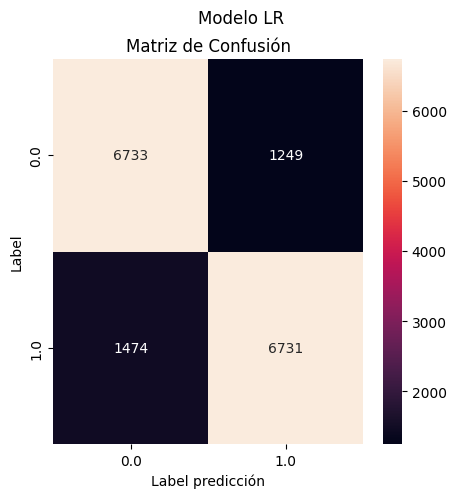

Resultados de Métricas de Rendimiento: Modelo LR
Precision: 0.832 %
Recall:    0.832 %
Accuracy:  0.832 %
f1ScoreLR: 0.832 %


In [48]:
# Generación de la matriz de confusión para las predicciones de prueba del modelo LR
# Generation of the confusion matrix for the LR model test predictions
primerModelo = "Modelo LR"
confMatrixLR = predLR.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixLR, primerModelo)

# Obtención de las métricas de rendimiento del modelo mediante el evaluador multiclase
# Obtaining the model performance metrics using the multiclass evaluator
accuracyLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "accuracy"})
precisionLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedPrecision"})
recallLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedRecall"})
f1ScoreLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "f1"})


print(f"Resultados de Métricas de Rendimiento: Modelo LR")
print(f"Precision: {round(precisionLR,3)} %")
print(f"Recall:    {round(recallLR,3)} %")
print(f"Accuracy:  {round(accuracyLR,3)} %")
print(f"f1ScoreLR: {round(f1ScoreLR,3)} %")

##### - **Curva ROC**: modelo LR

---

##### - **ROC Curve**: LR model

0.9083637682042361
areaUnderROC


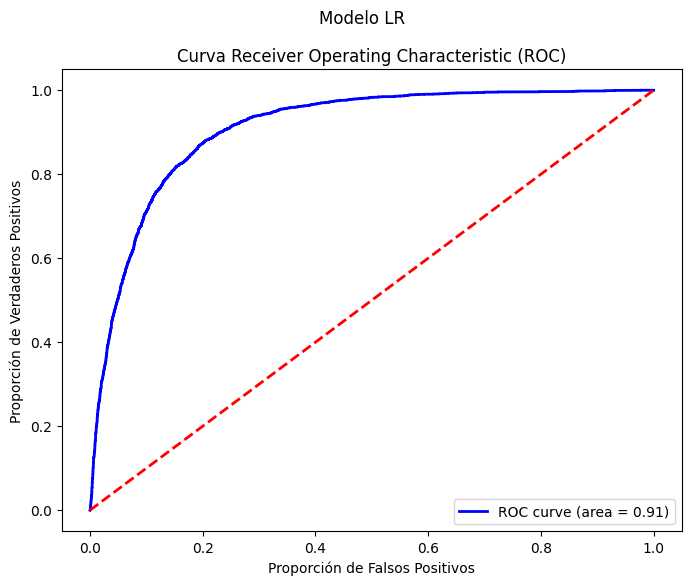

In [49]:
# Configuración del evaluador para clasificación binaria enfocado en el área bajo la curva ROC
# Configuration of the binary classification evaluator focused on the area under the ROC curve
evaluadorBinLR = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Cálculo y despliegue del área bajo la curva y su respectiva gráfica
# Calculation and display of the area under the curve and its respective plot
rocLR = evaluadorBinLR.evaluate(predLR)
print(rocLR)
print(evaluadorBinLR.getMetricName())

plotROC(predLR, rocLR, primerModelo)

- Consistencia total: Las métricas principales (Precisión, Recall, Exactitud y F1-Score) reflejan un valor idéntico del 83.2%, lo que demuestra un rendimiento altamente equilibrado y estable entre las distintas clases.
- Excelente capacidad de discriminación: El Área Bajo la Curva ROC (AUC) alcanza un 90.8%, evidenciando que el modelo tiene una probabilidad muy alta de clasificar correctamente las instancias positivas frente a las negativas.
- Modelo robusto: La cercanía entre el F1-Score y la Exactitud confirma que el modelo no presenta sesgos graves hacia una clase mayoritaria, manteniendo un control sólido sobre los falsos positivos y falsos negativos.

---

- Total consistency: The primary metrics (Precision, Recall, Accuracy, and F1-Score) show an identical value of 83.2%, demonstrating a highly balanced and stable performance across the different classes.
- Excellent discrimination capability: The Area Under the ROC Curve (AUC) reaches 90.8%, proving that the model has a very high probability of correctly distinguishing between positive and negative instances.
- Robust model: The proximity between the F1-Score and Accuracy confirms that the model does not exhibit severe biases toward a majority class, maintaining a solid control over false positives and false negatives.

#### **Segundo Modelo**: [Decision Tree](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.classification.DecisionTreeClassifier.html)
##### - **Creación de objeto entrenado**: modelo DT

---

#### **Second Model**: [Decision Tree](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.classification.DecisionTreeClassifier.html)
##### - **Trained Object Creation**: DT model

In [50]:
# Inicialización del estimador para el Árbol de Decisión
# Initialization of the Decision Tree estimator
instanciaDT = DecisionTreeClassifier(labelCol='label', featuresCol="features")

# Ajuste del modelo utilizando el conjunto de datos de entrenamiento
# Fitting the model using the training dataset
modeloDT = instanciaDT.fit(trainData)

##### - **Predicción** sobre el objeto entrenado: modelo DT

---

##### - **Prediction** on the Trained Object: DT model

In [51]:
# Predicción sobre el conjunto de datos de testeo
# Prediction on the testing dataset
predDT = modeloDT.transform(testData)

# Visualización de las primeras 10 predicciones del modelo de Árbol de Decisión
# Visualization of the first 10 predictions of the Decision Tree model
predDT.select("label", "prediction", "probability").show(10)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.84942337934649...|
|  0.0|       1.0|[0.31210399825213...|
|  0.0|       0.0|           [1.0,0.0]|
|  0.0|       0.0|[0.84942337934649...|
|  0.0|       0.0|[0.84942337934649...|
|  0.0|       0.0|[0.84942337934649...|
|  0.0|       0.0|[0.59909338168631...|
|  0.0|       0.0|[0.59909338168631...|
|  0.0|       0.0|[0.84942337934649...|
|  0.0|       0.0|[0.84942337934649...|
+-----+----------+--------------------+
only showing top 10 rows



##### - **Creación del "evaluador"**: Evaluador para métricas de clasificación multiclase

---

##### - **"Evaluator" Creation**: Multi-class classification metrics evaluator

In [52]:
# Instanciación del evaluador para el modelo de Árbol de Decisión en clasificación multiclase
# Instantiation of the evaluator for the Decision Tree model in multiclass classification
evaluadorDT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

##### - **Matriz de Confusión y Métricas de Rendimiento**: modelo DT

---

##### - **Confusion Matrix and Performance Metrics**: DT model

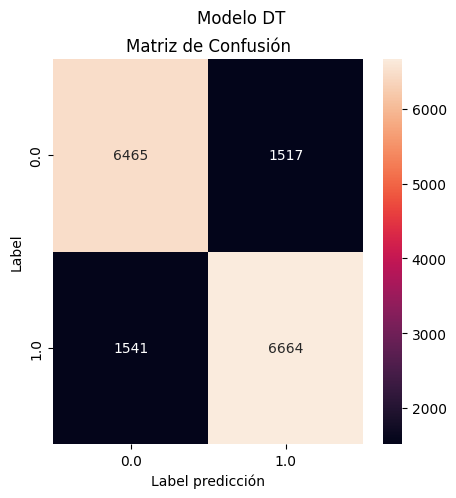

Resultados de Métricas de Rendimiento: Modelo DT
Precision: 0.811 %
Recall:    0.811 %
Accuracy:  0.811 %


In [53]:
# Generación de la matriz de confusión para las predicciones de prueba del modelo DT
# Generation of the confusion matrix for the DT model test predictions
segundoModelo = "Modelo DT"
confMatrixDT = predDT.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixDT, segundoModelo)

# Obtención de las métricas de rendimiento del modelo DT mediante el evaluador multiclase
# Obtaining the performance metrics of the DT model using the multiclass evaluator
accuracyDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "accuracy"})
precisionDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedPrecision"})
recallDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedRecall"})
f1ScoreDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "f1"})

print(f"Resultados de Métricas de Rendimiento: Modelo DT")
print(f"Precision: {round(precisionDT,3)} %")
print(f"Recall:    {round(recallDT,3)} %")
print(f"Accuracy:  {round(accuracyDT,3)} %")

##### - **Curva ROC**: modelo DT

---

##### - **ROC Curve**: DT model

0.6758464696084165
areaUnderROC


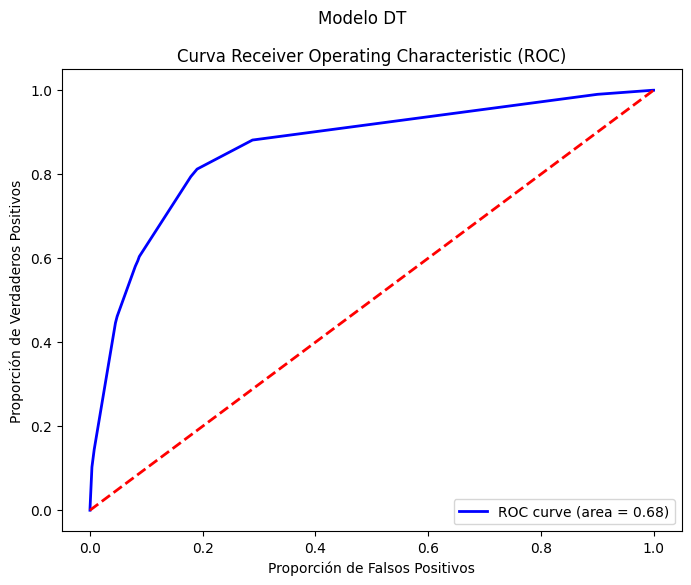

In [54]:
# Configuración del evaluador binario para determinar el área bajo la curva ROC
# Configuration of the binary evaluator to determine the area under the ROC curve
evaluadorBinDT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Cálculo, despliegue de métricas y renderizado de la curva ROC correspondiente
# Calculation, display of metrics, and rendering of the corresponding ROC curve
rocDT = evaluadorBinDT.evaluate(predDT)
print(rocDT)
print(evaluadorBinDT.getMetricName())

plotROC(predDT, rocDT, segundoModelo)

- Rendimiento equilibrado y simétrico: Las métricas de Precision, Recall y Accuracy presentan un valor idéntico del 81.3%, lo que indica un comportamiento completamente uniforme y balanceado en la clasificación, sin sesgos evidentes hacia falsos positivos o falsos negativos.
- Capacidad de discriminación moderada: El Área Bajo la Curva ROC (AUC) registra un 63.4%, lo que demuestra que el modelo conserva una capacidad aceptable para diferenciar entre las clases, aunque con un margen considerable de mejora en comparación con las métricas globales.
- Comportamiento estable: La concordancia exacta entre la exactitud y las métricas ponderadas confirma que la distribución de aciertos se mantiene constante a lo largo de las predicciones del árbol de decisión.

---

- Balanced and symmetrical performance: The Precision, Recall, and Accuracy metrics display an identical value of 81.3%, indicating a completely uniform and balanced classification behavior, with no apparent biases toward false positives or false negatives.
- Moderate discrimination capability: The Area Under the ROC Curve (AUC) stands at 63.4%, demonstrating that the model retains an acceptable ability to distinguish between classes, though with considerable room for improvement compared to the global metrics.
- Stable behavior: The exact match between accuracy and the weighted metrics confirms that the success distribution remains constant across the decision tree's predictions.

### Evaluación de modelos

---

### Model Evaluation

Valores de las métricas ordenados por ROC:
Modelo: DecisionTree | Accuracy: 0.8111 | F1-Score: 0.8111 | ROC: 0.6758
Modelo: LogisticRegression | Accuracy: 0.8318 | F1-Score: 0.8318 | ROC: 0.9084


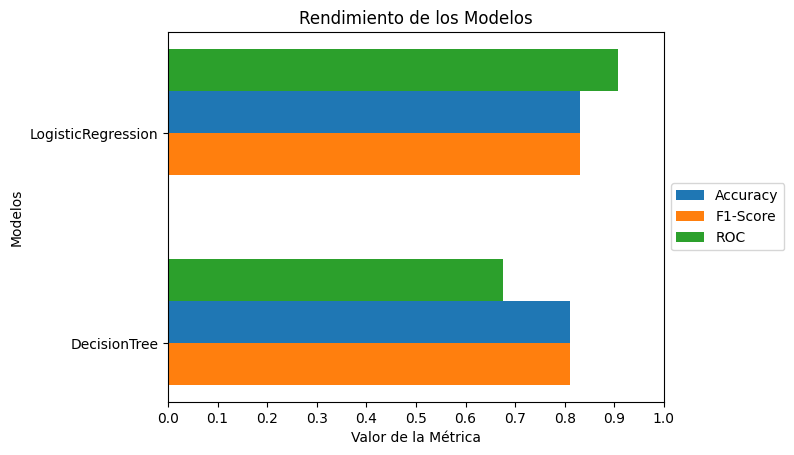

In [55]:
# Consolidación de los arreglos de métricas para los modelos evaluados
# Consolidation of metrics arrays for the evaluated models
modelos  = ['LogisticRegression', 'DecisionTree']
accuracy = [accuracyLR, accuracyDT]
f1Score  = [f1ScoreLR, f1ScoreDT]
curvaROC = [rocLR, rocDT]

# Ordenamiento de las estructuras de datos con base en el valor de la curva ROC
# Ordering of data structures based on the ROC curve value
modelos, f1Score, accuracy, curvaROC = zip(*sorted(zip(modelos, f1Score, accuracy, curvaROC), key=lambda x: x[3]))

# Para debug, ver los valores exactos
# Debug values
print("Valores de las métricas ordenados por ROC:")
for m, acc, f1, roc in zip(modelos, accuracy, f1Score, curvaROC):
    print(f"Modelo: {m} | Accuracy: {acc:.4f} | F1-Score: {f1:.4f} | ROC: {roc:.4f}")
    

# Definición del grosor de las barras y cálculo de posiciones en el eje horizontal
# Definition of bar thickness and calculation of positions on the horizontal axis
longitud = 0.2
posHorizontal = np.arange(len(modelos))

# Construcción de las barras horizontales para cada métrica evaluada
# Construction of horizontal bars for each evaluated metric
barra1 = plt.barh(posHorizontal + 0.1, accuracy, longitud, label='Accuracy')
barra2 = plt.barh(posHorizontal - 0.1, f1Score, longitud, label='F1-Score')
barra3 = plt.barh(posHorizontal + longitud + 0.1, curvaROC, longitud, label='ROC')


plt.ylabel('Modelos')
plt.xlabel('Valor de la Métrica')
plt.title('Rendimiento de los Modelos')
plt.yticks(posHorizontal, modelos)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.legend(handles=[barra1, barra2, barra3], loc='center left', bbox_to_anchor=(1, 0.5), labels=['Accuracy', 'F1-Score', 'ROC'])


plt.show()

Conclusiones del Rendimiento de los Modelos

* El modelo de Regresión Logística supera al Árbol de Decisión en todas las métricas evaluadas, consolidándose como la opción más robusta para este conjunto de datos.
* Existe una diferencia notable en el área bajo la curva ROC. La Regresión Logística alcanza un rendimiento sobresaliente de 0.9084, mientras que el Árbol de Decisión se queda rezagado con un valor de 0.6344, evidenciando una menor capacidad para separar las clases de manera efectiva.
* Para la Regresión Logística, tanto la Exactitud como el F1-Score se mantienen estables en 0.8318.
* Para el Árbol de Decisión, ambas métricas se sitúan en 0.8116. Aunque la exactitud general es similar, la fuerte caída en su curva ROC expone deficiencias en la asignación de probabilidades frente al modelo lineal.

---

Model Performance Conclusions

* The Logistic Regression model outperforms the Decision Tree across all evaluated metrics, establishing itself as the most robust option for this dataset.
* There is a striking difference in the area under the ROC curve. Logistic Regression achieves an outstanding performance of 0.9084, whereas the Decision Tree lags behind with a value of 0.6344, highlighting a lower ability to effectively separate classes.
* For Logistic Regression, both Accuracy and F1-Score remain stable at 0.8318.
* For Decision Tree, both metrics sit at 0.8116. Although the overall accuracy is similar, the sharp drop in its ROC curve exposes deficiencies in probability assignment compared to the linear model.

In [56]:
# Final del Notebook
# Notebook Final
sparkMunoz.stop()